<a href="https://colab.research.google.com/github/marvinjc/proyecto_final_CD/blob/main/cd_final_proyecto_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/marvinjc/proyecto_final_CD/blob/main/cd_final_proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto final: Aguas superficiales CONAGUA 2020
Limpieza, EDA, preparación (Pipeline) y K-means geográfico

Flujo OSEMN: Obtain → Scrub → Explore → Model → Interpret.


*   Obtener:     Recopilar los datos de diferentes fuentes.
*   Scrub:       Corregir errores, datos faltantes, duplicados y formatos.
*   Explorar:    Analizar los datos mediante estadísticas y gráficos para encontrar patrones.
*   Modelar:     Aplicar modelos estadísticos o de aprendizaje automático.
*   Interpretar: Explicar los resultados y obtener conclusiones útiles.




In [1]:
# Importamos las librerías y definimos las rutas utilizadas en el análisis.
from pathlib import Path
from urllib.parse import urlparse

# NumPy: permite trabajar con arreglos y realizar cálculos numéricos
# de manera rápida y eficiente.
import numpy as np

# Pandas: permite trabajar y analizar datos en forma de tablas
# (DataFrames), similar a una hoja de Excel.
import pandas as pd

# Matplotlib: permite crear gráficos y visualizaciones de los datos.
import matplotlib.pyplot as plt

# Seaborn: permite crear gráficos estadísticos de una forma más sencilla
# y con una presentación visual más elaborada.
import seaborn as sns

# KMeans: algoritmo de aprendizaje no supervisado que permite agrupar
# los datos en diferentes grupos o "clusters".
from sklearn.cluster import KMeans

# ColumnTransformer: permite aplicar diferentes transformaciones
# a diferentes columnas de un conjunto de datos.
from sklearn.compose import ColumnTransformer

# SimpleImputer: permite reemplazar valores faltantes o vacíos
# utilizando estrategias como la media, mediana o valor más frecuente.
from sklearn.impute import SimpleImputer

# silhouette_score: permite evaluar qué tan bien separados están los
# grupos creados por un algoritmo de clustering como KMeans.
from sklearn.metrics import silhouette_score

# Pipeline: permite organizar varias etapas de procesamiento y modelado
# en una sola secuencia, facilitando el flujo de trabajo.
from sklearn.pipeline import Pipeline

# MinMaxScaler: transforma los valores de las variables para llevarlos
# normalmente a un rango entre 0 y 1.
# FunctionTransformer: permite aplicar una función personalizada
# a los datos durante el proceso de transformación.
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer

sns.set_theme(style="whitegrid")
RUTA_SITIOS = "https://raw.githubusercontent.com/marvinjc/proyecto_final_CD/main/Datos_de_calidad_del_agua_de_sitios_de_monitoreo_de_aguas_superficiales_2020.csv"
RUTA_ESCALAS = "https://raw.githubusercontent.com/marvinjc/proyecto_final_CD/main/Escalas_superficial.csv"


def es_url_https_valida(url: str) -> bool:
    """Valida que una ruta remota use HTTPS y contenga un dominio."""
    try:
        resultado = urlparse(url)
        return resultado.scheme == "https" and bool(resultado.netloc)
    except ValueError:
        return False

## 1. Carga e inspección inicial

OSEMN Obtain: se carga el CSV CONAGUA 2020 y se revisa forma, tipos y muestra.

In [2]:
# Leemos el archivo CSV crudo de los datos de la calidad del agua.
df_crudo = pd.read_csv(RUTA_SITIOS, encoding="latin-1")

In [3]:
# .shape nos muestra la cantidad de filas y columnas en el archivo
df_crudo.shape

(4141, 55)

In [4]:
# Visualizamos la lista de los nombres de la columnas
df_crudo.columns

Index(['CLAVE', 'SITIO', 'ORGANISMO_DE_CUENCA', 'ESTADO', 'MUNICIPIO',
       'CUENCA', 'CUERPO DE AGUA', 'TIPO', 'SUBTIPO', 'LONGITUD', 'LATITUD',
       'PERIODO', 'DBO_mg/L', 'CALIDAD_DBO', 'DQO_mg/L', 'CALIDAD_DQO',
       'SST_mg/L', 'CALIDAD_SST', 'COLI_FEC_NMP_100mL', 'CALIDAD_COLI_FEC',
       'E_COLI_NMP_100mL', 'CALIDAD_E_COLI', 'ENTEROC_NMP_100mL',
       'CALIDAD_ENTEROC', 'OD_PORC', 'CALIDAD_OD_PORC', 'OD_PORC_SUP',
       'CALIDAD_OD_PORC_SUP', 'OD_PORC_MED', 'CALIDAD_OD_PORC_MED',
       'OD_PORC_FON', 'CALIDAD_OD_PORC_FON', 'TOX_D_48_UT', 'CALIDAD_TOX_D_48',
       'TOX_V_15_UT', 'CALIDAD_TOX_V_15', 'TOX_D_48_SUP_UT',
       'CALIDAD TOX_D_48_SUP', 'TOX_D_48_FON_UT', 'CALIDAD_TOX_D_48_FON',
       'TOX_FIS_SUP_15_UT', 'CALIDAD_TOX_FIS_SUP_15', 'TOX_FIS_FON_15_UT',
       'CALIDAD_TOX_FIS_FON_15', 'SEMAFORO', 'CONTAMINANTES', 'CUMPLE_CON_DBO',
       'CUMPLE_CON_DQO', 'CUMPLE_CON_SST', 'CUMPLE_CON_CF',
       'CUMPLE_CON_E_COLI', 'CUMPLE_CON_ENTEROC', 'CUMPLE_CON_OD',
  

In [5]:
# Descubrimos el tipo de dato que contine cada columna
df_crudo.dtypes

,0
CLAVE,object
SITIO,object
ORGANISMO_DE_CUENCA,object
ESTADO,object
MUNICIPIO,object
CUENCA,object
CUERPO DE AGUA,object
TIPO,object
SUBTIPO,object
LONGITUD,float64


In [6]:
# Imprime el encabezado de del dataframe, se observa que no imprime todas las columnas existentes.
df_crudo.head()

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,...,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
0,DLAGU8,PRESA EL SAUCILLO 100M AGUAS ARRIBA DE LA CORTINA,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,RINCON DE ROMOS,RIO SAN PEDRO,PRESA EL SAUCILLO,LENTICO,PRESA,-102.33911,...,"DQO,CF,",SI,NO,SI,NO,SI,ND,SI,SI,LENTICO
1,DLBAJ100,"LOS CABOS SEG 22, 2 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN JOSE DEL CABO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.84290,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
2,DLBAJ101,"LOS CABOS SEG 22, 1 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.86442,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
3,DLBAJ102,LOS CABOS 3,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.88604,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
4,DLBAJ103,LOS CABOS 1,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.89657,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO


In [7]:
# Visualizar todo el encabezado del dataframe incluyendo todas las columnas existentes
with pd.option_context('display.max_columns', None):
    display(df_crudo.head())

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,LATITUD,PERIODO,DBO_mg/L,CALIDAD_DBO,DQO_mg/L,CALIDAD_DQO,SST_mg/L,CALIDAD_SST,COLI_FEC_NMP_100mL,CALIDAD_COLI_FEC,E_COLI_NMP_100mL,CALIDAD_E_COLI,ENTEROC_NMP_100mL,CALIDAD_ENTEROC,OD_PORC,CALIDAD_OD_PORC,OD_PORC_SUP,CALIDAD_OD_PORC_SUP,OD_PORC_MED,CALIDAD_OD_PORC_MED,OD_PORC_FON,CALIDAD_OD_PORC_FON,TOX_D_48_UT,CALIDAD_TOX_D_48,TOX_V_15_UT,CALIDAD_TOX_V_15,TOX_D_48_SUP_UT,CALIDAD TOX_D_48_SUP,TOX_D_48_FON_UT,CALIDAD_TOX_D_48_FON,TOX_FIS_SUP_15_UT,CALIDAD_TOX_FIS_SUP_15,TOX_FIS_FON_15_UT,CALIDAD_TOX_FIS_FON_15,SEMAFORO,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
0,DLAGU8,PRESA EL SAUCILLO 100M AGUAS ARRIBA DE LA CORTINA,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,RINCON DE ROMOS,RIO SAN PEDRO,PRESA EL SAUCILLO,LENTICO,PRESA,-102.33911,22.24730,2020.0,6,Buena calidad,54.08,Contaminada,13.75,Excelente,1162,Contaminada,98,Excelente,NaN,NaN,NaN,NaN,46.8,Aceptable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,<1,No Toxico,NaN,NaN,Rojo,"DQO,CF,",SI,NO,SI,NO,SI,ND,SI,SI,LENTICO
1,DLBAJ100,"LOS CABOS SEG 22, 2 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN JOSE DEL CABO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.84290,22.90473,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,20,Excelente,NaN,NaN,92,Excelente,95.4,Excelente,92.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
2,DLBAJ101,"LOS CABOS SEG 22, 1 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.86442,22.89880,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,<3,Excelente,NaN,NaN,92,Excelente,95.4,Excelente,92.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
3,DLBAJ102,LOS CABOS 3,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.88604,22.89609,2020.0,NaN,NaN,NaN,NaN,13.9667,Excelente,NaN,NaN,NaN,NaN,<3,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,86.7,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
4,DLBAJ103,LOS CABOS 1,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.89657,22.87694,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,30,Excelente,NaN,NaN,96.2,Excelente,95.9,Excelente,95.5,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO


### Observación 1
Las primeras 12 columnas contienen información pertinente a los lugares donde se realizó la toma de agua, el periodo en el tiempo y las características.
1.   CLAVE
2.   SITIO
3.   ORGANISMO_DE_CUENCA
4.   ESTADO
5.   MUNICIPIO
6.   CUENCA
7.   CUERPO DE AGUA
8.   TIPO
9.   SUBTIPO
10.  LONGITUD
11.  LATITUD
12.  PERIODO

In [8]:
# Ver valores únicos
df_crudo['CLAVE'].unique()

array(['DLAGU8', 'DLBAJ100', 'DLBAJ101', ..., 'OCRBR5209M1',
       'OCRBR5210M1', nan], dtype=object)

In [9]:
# Contar valores únicos
df_crudo['CLAVE'].nunique()

3493

In [10]:
# Contar cuántas veces aparece cada valor
df_crudo['CLAVE'].value_counts()

,count
CLAVE,
OCRBR5210M1,1
DLAGU8,1
DLBAJ100,1
DLBAJ101,1
DLBAJ102,1
...,...
DLBAJ112,1
DLBAJ109,1
DLBAJ106W2,1


In [11]:
# Visualizar todos los valores del sitio
print(df_crudo['SITIO'].value_counts().to_string())

SITIO
ANTES DE LA CONFLUENCIA CON EL RIO ATOYAC                                                                                                          3
PRESA DERIVADORA MORELOS                                                                                                                           2
PRESA BENITO JUAREZ CORTINA                                                                                                                        2
PEÑA BLANCA                                                                                                                                        2
EL PUENTE                                                                                                                                          2
LAS ADJUNTAS                                                                                                                                       2
PRESA TEPUXTEPEC                                                                                    

In [12]:
# Revisamos las frecuencias de las primeras doce columnas.
for columna in df_crudo.columns[:12]:
    print(f"\n--- {columna} ---")
    print(df_crudo[columna].value_counts(dropna=False))


--- CLAVE ---
CLAVE
NaN            648
OCGNO3502M1      1
OCGNO3503        1
OCGNO3504        1
OCGNO3505        1
              ... 
DLPUE2007        1
DLPUE2008        1
DLPUE2009        1
DLPUE2010        1
DLPUE1997        1
Name: count, Length: 3494, dtype: int64

--- SITIO ---
SITIO
NaN                                          648
ANTES DE LA CONFLUENCIA CON EL RIO ATOYAC      3
PRESA BENITO JUAREZ CORTINA                    2
PRESA DERIVADORA MORELOS                       2
EL PUENTE                                      2
                                            ... 
LAZARO CARDENAS                                1
AGUA FRIA                                      1
RIO CAZONES 5                                  1
VILLA AVILA CAMACHO                            1
PRESA TENANGO                                  1
Name: count, Length: 3482, dtype: int64

--- ORGANISMO_DE_CUENCA ---
ORGANISMO_DE_CUENCA
LERMA SANTIAGO PACIFICO         709
NaN                             648
FRONTERA 

### Observación 2
El resulutado del df_crudo.shape muestra que hay una total de 4141 columnas. Al verificar la cuenta de valores en las columnas se observa un dato importante a utilizar en la limpieza de los datos:

NaN significa “Not a Number”, pero en Pandas normalmente se utiliza para representar un dato faltante o vacío.

* NaN = 648
* Periodo 2020.o 3493

Si al valor total de columnas 4141 le restamos el valor NaN encontrado en la cuenta de las columnas, nos damos cuenta que tenemos 3493 filas que en su mayoría si deberían tener un dato valido.  Definitivamente algunos de esos datos van a necesitar una transformación, pero es importante resaltar la importancia de haber encontrado la cantidad de datos faltantes o vacio.  

In [13]:
# Revisamos las frecuencias de las columnas restantes.
for columna in df_crudo.columns[12:]:
    print(f"\n--- {columna} ---")
    print(df_crudo[columna].value_counts(dropna=False))


--- DBO_mg/L ---
DBO_mg/L
NaN      1560
<2       1224
6          23
9          20
8          14
         ... 
38.9        1
33.42       1
18.86       1
11.06       1
7.68        1
Name: count, Length: 744, dtype: int64

--- CALIDAD_DBO ---
CALIDAD_DBO
NaN                        1560
Excelente                  1330
Aceptable                   672
Buena calidad               317
Contaminada                 201
Fuertemente contaminada      61
Name: count, dtype: int64

--- DQO_mg/L ---
DQO_mg/L
NaN      1560
<10       559
12.29      12
16.04      11
17.64      10
         ... 
34.42       1
49.78       1
21.96       1
57.12       1
42.72       1
Name: count, Length: 1212, dtype: int64

--- CALIDAD_DQO ---
CALIDAD_DQO
NaN                        1560
Contaminada                 790
Aceptable                   635
Excelente                   562
Buena calidad               453
Fuertemente contaminada     141
Name: count, dtype: int64

--- SST_mg/L ---
SST_mg/L
<10        880
NaN        652


### Investigación
**DBO_mg/L**

DBO_mg/L significa Demanda Bioquímica de Oxígeno, medida en miligramos por litro (mg/L).

Es un indicador de contaminación orgánica del agua. Mide cuánto oxígeno necesitan los microorganismos para descomponer la materia orgánica presente en el agua.

En términos sencillos:

🟢 DBO baja → poca materia orgánica biodegradable, generalmente mejor calidad del agua.

🟡 DBO media → mayor presencia de materia orgánica.

🔴 DBO alta → mucha materia orgánica, lo que puede consumir gran cantidad de oxígeno y afectar a los organismos acuáticos.

**DQO_mg/L**

DQO_mg/L significa Demanda Química de Oxígeno, medida en miligramos por litro (mg/L).

Indica la cantidad de oxígeno necesaria para oxidar químicamente la materia orgánica y otras sustancias oxidables presentes en el agua.

**SST_mg/L**

ST_mg/L significa Sólidos Suspendidos Totales, medidos en miligramos por litro (mg/L).

Mide la cantidad de partículas sólidas que están suspendidas en el agua, por ejemplo:

🌱 Tierra y sedimentos

🪨 Arcilla

🌿 Restos de materia orgánica

🦠 Microorganismos


Otros materiales pequeños que no están disueltos
SST	Interpretación general
* Bajo	Agua relativamente clara, pocas partículas suspendidas

* Medio	Mayor cantidad de sedimentos o partículas

* Alto	Agua con bastante material suspendido y turbidez

**COLI_FEC_NMP_100mL**
COLI_FEC_NMP_100mL significa Coliformes fecales, Número Más Probable por cada 100 mL de agua.

Es una medida de contaminación microbiológica, especialmente relacionada con contaminación de origen fecal.


*   Bajo	Menor evidencia de contaminación fecal
*   Medio	Mayor presencia de contaminación fecal
*   Alto	Fuerte indicio de contaminación fecal

**E_COLI_NMP_100mL**

E_COLI_NMP_100mL significa Escherichia coli (E. coli), medida como Número Más Probable por cada 100 mL de agua.

E_COLI → Escherichia coli, bacteria que normalmente se encuentra en el intestino de personas y animales.
NMP → Número Más Probable, una estimación estadística de la cantidad de bacterias.
100 mL → cantidad de agua utilizada como referencia.

La presencia de E. coli es un indicador importante de contaminación fecal reciente.
* 0	No se detecta E. coli
* Bajo	Presencia pequeña
* Alto	Mayor evidencia de contaminación fecal
COLI_FEC representa un grupo de bacterias indicadoras, mientras que E_COLI se refiere específicamente a E. coli. Por eso, aunque están relacionadas, no son exactamente la misma variable.

E_COLI es una variable especialmente relevante para evaluar contaminación microbiológica.

**ENTEROC_NMP_100mL**

ENTEROC_NMP_100mL significa Enterococos, medidos como Número Más Probable por cada 100 mL de agua.
* ENTEROC → Enterococos, un grupo de bacterias que puede encontrarse en el intestino de humanos y animales.
* NMP → Número Más Probable, una estimación estadística de la cantidad de microorganismos.
* 100 mL → cantidad de agua utilizada como referencia.

Los enterococos son indicadores de contaminación fecal. Su presencia puede indicar que el agua ha estado expuesta a contaminación proveniente de materia fecal.

* 0	No se detectan enterococos
* Bajo	Menor presencia de contaminación fecal
* Alto	Mayor evidencia de contaminación fecal

**OD_PORC**

Significa Oxígeno Disuelto en porcentaje (%).

Mide cuánto oxígeno está disuelto en el agua en relación con la cantidad máxima de oxígeno que el agua puede contener bajo las condiciones de medición.

* Alto	Buena disponibilidad de oxígeno para organismos acuáticos
* Medio	Disponibilidad moderada
* Bajo	Puede indicar condiciones desfavorables para la vida acuática

Importante: aquí hay una diferencia con DBO y DQO. En esas variables, un valor alto generalmente representa una mayor carga de materia oxidable. En **OD**, normalmente interesa que exista suficiente oxígeno disponible.

* OD alto → más oxígeno disponible 🐟
* OD bajo → menos oxígeno disponible ⚠️

**OD_PORC_SUP**

OD_PORC_SUP probablemente significa Oxígeno Disuelto en porcentaje de saturación superficial.

OD → Oxígeno Disuelto.

PORC → Porcentaje.

SUP → Superficial.

Es decir, representa el porcentaje de saturación de oxígeno disuelto medido en la superficie del cuerpo de agua.

**OD_PORC_MED**

OD_PORC_MED probablemente significa Oxígeno Disuelto en porcentaje de saturación media.

OD → Oxígeno Disuelto

PORC → Porcentaje

MED → Medición media o promedio

**CALIDAD_OD_PORC_FON**

CALIDAD_OD_PORC_FON probablemente significa Calidad del Oxígeno Disuelto (%) en el fondo.

Descomponiendo el nombre:

* CALIDAD → clasificación o categoría de calidad.
* OD → Oxígeno Disuelto.
* PORC → porcentaje de saturación.
* FON → fondo del cuerpo de agua.

Por tanto, esta columna no contiene el valor numérico del oxígeno, sino una clasificación de su calidad en el fondo.


**TOX_D_48_UT**

TOX_D_48_UT probablemente corresponde a un ensayo de toxicidad de 48 horas, **pero aquí sí conviene confirmar el diccionario de datos antes de darle un significado exacto.**

Una interpretación probable del nombre es:

* TOX → Toxicidad
* D → probablemente una abreviatura específica del tipo de ensayo
* 48 → duración de 48 horas
* UT → probablemente Unidades de Toxicidad

Es una variable relacionada con el efecto tóxico que una muestra de agua puede producir sobre un organismo de prueba durante 48 horas.

**TOX_V_15_UT**

TOX_V_15_UT parece ser una variable de toxicidad, y por su estructura probablemente se refiere a un ensayo de toxicidad de 15 minutos, expresado en Unidades de Toxicidad (UT).

Descomponiendo el nombre:

* TOX → Toxicidad
* V → tipo específico de ensayo o organismo utilizado
* 15 → duración del ensayo, probablemente 15 minutos
* UT → Unidades de Toxicidad

**TOX_D_48_SUP_UT**

TOX_D_48_SUP_UT parece ser una variable relacionada con toxicidad, y por su nombre podemos descomponerla así:

* TOX → Toxicidad
* D → tipo de ensayo o método
* 48 → duración de 48 horas
* SUP → probablemente superficie
* UT → Unidades de Toxicidad

Por lo tanto, probablemente representa la toxicidad medida mediante un ensayo de 48 horas en una muestra superficial, expresada en Unidades de Toxicidad.

**TOX_D_48_FON_UT**
TOX_D_48_FON_UT parece representar un indicador de toxicidad medido en el fondo del cuerpo de agua.

Descomponiendo el nombre:

* TOX → Toxicidad
* D → tipo de ensayo o método
* 48 → duración de 48 horas
* FON → fondo
* UT → Unidades de Toxicidad

Por tanto, la interpretación probable sería:

Toxicidad determinada mediante un ensayo de 48 horas en una muestra del fondo, expresada en Unidades de Toxicidad (UT).

**TOX_FIS_SUP_15_UT**

* TOX → Toxicidad
* FIS → corresponde a un tipo específico de ensayo de toxicidad
* SUP → superficie
* 15 → ensayo de 15 minutos
* UT → Unidades de Toxicidad

**TOX_FIS_FON_15_UT**

TOX_FIS_FON_15_UT es una variable relacionada con la toxicidad del agua, y por la estructura de tu dataset podemos descomponerla así:

* TOX → Toxicidad
* FIS → tipo específico de ensayo de toxicidad
* FON → Fondo
* 15 → ensayo de 15 minutos
* UT → Unidades de Toxicidad



### Observación 3
Entendiendo las columnas, los que significa cada una de ellas y el patrón o estructura de los datos, se pueden clasificar de la siguiente forma:

* Información geográfica
* Mediciones de calidad
* Clasificaciones
* Indicadores de cumplimiento
* Resultado final


Detalle de las clasificaciones

* **Información geográfica**

CLAVE, SITIO, ORGANISMO_DE_CUENCA, ESTADO, MUNICIPIO
, CUENCA, CUERPO DE AGUA, TIPO, SUBTIPO, LONGITUD, LATITUD, PERIODO

* **Mediciones de calidad**
1. Materia orgánica

DBO_mg/L → Demanda Bioquímica de Oxígeno (DBO)
DQO_mg/L → Demanda Química de Oxígeno (DQO)

2. Sólidos suspendidos

SST_mg/L → Sólidos Suspendidos Totales (SST)

3. Contaminación microbiológica

COLI_FEC_NMP_100mL → Coliformes Fecales
E_COLI_NMP_100mL → Escherichia coli
ENTEROC_NMP_100mL → Enterococos

4. Oxígeno disuelto

OD_PORC → Oxígeno Disuelto
OD_PORC_SUP → Oxígeno Disuelto en Superficie
OD_PORC_MED → Oxígeno Disuelto en Zona Media
OD_PORC_FON → Oxígeno Disuelto en Fondo

5. Toxicidad

TOX_D_48_UT → Toxicidad, ensayo de 48 horas
TOX_V_15_UT → Toxicidad, ensayo de 15 minutos
TOX_D_48_SUP_UT → Toxicidad en Superficie, ensayo de 48 horas
TOX_D_48_FON_UT → Toxicidad en Fondo, ensayo de 48 horas
TOX_FIS_SUP_15_UT → Toxicidad en Superficie, ensayo de 15 minutos
TOX_FIS_FON_15_UT → Toxicidad en Fondo, ensayo de 15 minutos

* Indicadores de cumplimiento

CUMPLE_CON_DBO, CUMPLE_CON_DQO, CUMPLE_CON_SST, CUMPLE_CON_CF, CUMPLE_CON_E_COLI, CUMPLE_CON_ENTEROC, CUMPLE_CON_OD, CUMPLE_CON_TOX

* Resultado final

SEMAFORO

CONTAMINANTES

GRUPO





### Observación 4
Los datos carecen de un diccionario de datos/metadatos completo y actualizado de cada una de las mediciones con el significado de sus rangos y límites.

Parte de la comprensión del negocio consiste en identificar qué significa cada una y cuáles son las más importantes.

In [14]:
# Mostramos una muestra aleatoria de cinco registros.
df_crudo.sample(5, random_state=42)

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,...,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
2083,OCGCE3239,FELIPE CARRILLO PUERTO,GOLFO CENTRO,VERACRUZ DE IGNACIO DE LA LLAVE,MARTINEZ DE LA TORRE,RIO NAUTLA,RIO BOBOS,LOTICO (HUMEDAL),RIO,-96.95467,...,"CF,E_COLI,",SI,SI,SI,NO,NO,ND,SI,SI,LOTICO
1965,OCFSU3124,"PUERTO MADERO SEG 73, 3 ISA8",FRONTERA SUR,CHIAPAS,TAPACHULA,PUERTO MADERO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-92.41338,...,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
1582,DLTAB5561,MANATI 10,FRONTERA SUR,TABASCO,MACUSPANA,Chilapa,NaN,LOTICO,NaN,-92.30760,...,"CF,",SI,SI,SI,NO,SI,ND,ND,SI,LOTICO
296,DLDUR676M1,PRESA SANTIAGO BAYACORA,PACIFICO NORTE,DURANGO,DURANGO,RIO SANTIAGO BAYACORA,PRESA SANTIAGO BAYACORA,LENTICO (HUMEDAL),PRESA,-104.67751,...,NaN,SI,SI,SI,SI,SI,ND,SI,SI,LENTICO
149,DLCHI294,PLANTA NORTE,RIO BRAVO,CHIHUAHUA,JUAREZ,RIO BRAVO 1,CANAL,LOTICO,CANAL,-106.37040,...,NaN,SI,SI,SI,SI,SI,ND,SI,SI,LOTICO


In [15]:
# Consultamos las dimensiones, los tipos de datos y los valores no nulos.
print(df_crudo.shape)
df_crudo.info(verbose=True, show_counts=True)

(4141, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4141 entries, 0 to 4140
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLAVE                   3493 non-null   object 
 1   SITIO                   3493 non-null   object 
 2   ORGANISMO_DE_CUENCA     3493 non-null   object 
 3   ESTADO                  3493 non-null   object 
 4   MUNICIPIO               3493 non-null   object 
 5   CUENCA                  3492 non-null   object 
 6   CUERPO DE AGUA          3479 non-null   object 
 7   TIPO                    3493 non-null   object 
 8   SUBTIPO                 3479 non-null   object 
 9   LONGITUD                3493 non-null   float64
 10  LATITUD                 3493 non-null   float64
 11  PERIODO                 3493 non-null   float64
 12  DBO_mg/L                2581 non-null   object 
 13  CALIDAD_DBO             2581 non-null   object 
 14  DQO_mg/L                2581 

In [16]:
# Cargamos las escalas desde una ruta local o una URL HTTPS válida.
if Path(RUTA_ESCALAS).exists() or es_url_https_valida(RUTA_ESCALAS):
    escalas = pd.read_csv(RUTA_ESCALAS, encoding="latin-1")
    display(escalas.head(12))
else:
    print("La ruta de Escalas_superficial.csv no es un archivo local ni una URL HTTPS válida.")

,CALIDAD DEL AGUA PARA TOXICIDAD,CRITERIO,DESCRIPCION
0,No t¢xico,TOX menor a 1,Agua no contaminada.Toxicidad no detectable.
1,Toxicidad baja,TOX mayor o igual a 1 y menor o igual a 1.33,Toxicidad baja
2,Toxicidad moderada,TOX mayor de 1.33 y menor a 5,Toxicidad moderada
3,Toxicidad alta,TOX mayor o igual a 5,Toxicidad alta
4,CALIDAD DEL AGUA PARA SST,CRITERIO,DESCRIPCION
5,Excelente,SST menor o igual a 25,"Clase de excepci¢n, muy buena calidad."
6,Buena calidad,SST mayor de 25 y menor o igual a 75,Aguas superficiales con bajo contenido de soli...
7,Aceptable,SST mayor de 75 y menor o igual a 150,Aguas superficiales con indicio de contaminaci...
8,Contaminada,SST mayor de 150 y menor o igual a 400,Aguas superficiales de mala calidad con descar...
9,Fuertemente contaminada,SST mayor de 400,Aguas superficiales con fuerte impacto de desc...


## 2. Limpieza de datos
OSEMN Scrub: `a_numero`, LD/2 y nulos por GRUPO. No se pisa el CSV.

Rúbrica 2.5: Busqueda de nulos nulos, valores mal escritos (`<10`, `ND`) y sustitución (LD/2).

- `ND` / vacio -> NaN (no se midio; no se inventa un valor).
- `<10` -> 5: convencion (límite de detección)LD/2 para datos censurados. **No es la medicion exacta**; CONAGUA solo reporta que era menor al limite. Se usa para poder hacer describe, boxplot y correlacion.
- `>100` -> 100: se usa el limite; se pierde la distincion "mayor que".
- LATITUD / LONGITUD o SEMAFORO faltante: se elimina, **no se imputa**.

In [17]:
# Resumimos la cantidad y el porcentaje de valores nulos originales.
nulos_antes = df_crudo.isna().sum()
nulos_antes = nulos_antes[nulos_antes > 0].sort_values(ascending=False)
pd.DataFrame({
    "nulos": nulos_antes,
    "porcentaje": (nulos_antes / len(df_crudo) * 100).round(1),
})

,nulos,porcentaje
TOX_FIS_FON_15_UT,4141,100.0
CALIDAD_TOX_FIS_FON_15,4141,100.0
TOX_D_48_FON_UT,4141,100.0
CALIDAD_TOX_D_48_FON,4141,100.0
OD_PORC_MED,3654,88.2
CALIDAD_OD_PORC_MED,3654,88.2
CALIDAD TOX_D_48_SUP,3379,81.6
TOX_D_48_SUP_UT,3379,81.6
ENTEROC_NMP_100mL,3237,78.2
CALIDAD_ENTEROC,3237,78.2


In [18]:
# Definimos las columnas, categorías y funciones auxiliares del análisis.
Y = "SEMAFORO"
COLS_GEO = ["LONGITUD", "LATITUD"]
COLORES_SEMAFORO = {"Verde": "#2e7d32", "Amarillo": "#c98d00", "Rojo": "#c62828"}

COLS_LAB = [
    "DBO_mg/L", "DQO_mg/L", "SST_mg/L",
    "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL", "ENTEROC_NMP_100mL",
    "OD_PORC", "OD_PORC_SUP", "OD_PORC_MED", "OD_PORC_FON",
    "TOX_D_48_UT", "TOX_V_15_UT", "TOX_D_48_SUP_UT", "TOX_FIS_SUP_15_UT",
]

X_NUMERICAS = [
    "DBO_mg/L", "DQO_mg/L", "SST_mg/L",
    "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL", "ENTEROC_NMP_100mL",
    "OD_PORC", "OD_PORC_SUP",
]

def a_numero(valor):
    """'54.08' -> 54.08 | '<10' -> 5 (LD/2, convencion) | '>100' -> 100 | ND/vacio -> NaN"""
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip()
    if texto == "" or texto.upper() == "ND":
        return np.nan
    texto = texto.replace(",", "")
    if texto.startswith("<"):
        try:
            return float(texto[1:]) / 2.0
        except ValueError:
            return np.nan
    if texto.startswith(">"):
        try:
            return float(texto[1:])
        except ValueError:
            return np.nan
    try:
        return float(texto)
    except ValueError:
        return np.nan

In [19]:
# Limpiamos los registros y convertimos las variables seleccionadas a valores numéricos.
df = df_crudo.dropna(subset=["CLAVE"]).copy()
df["CLAVE"] = df["CLAVE"].astype(str).str.strip()
df = df[df["CLAVE"] != ""].copy()

for col in COLS_LAB + COLS_GEO:
    if col in df.columns:
        df[col] = df[col].map(a_numero)

df[Y] = df[Y].astype(str).str.strip().str.title()
df.loc[df[Y].isin(["Nan", "Nd", "None", ""]), Y] = np.nan

if "GRUPO" in df.columns:
    df["GRUPO"] = df["GRUPO"].astype(str).str.strip().str.upper()

n0 = len(df)
df = df.dropna(subset=COLS_GEO).copy()
print("Eliminadas por lat/lon faltante:", n0 - len(df))

n1 = len(df)
df = df.dropna(subset=[Y]).copy()
print("Eliminadas por SEMAFORO faltante:", n1 - len(df))
print("Sitios listos:", len(df))
df[COLS_LAB[:5] + COLS_GEO + [Y]].head()

Eliminadas por lat/lon faltante: 0
Eliminadas por SEMAFORO faltante: 0
Sitios listos: 3493


,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,LONGITUD,LATITUD,SEMAFORO
0,6.0,54.08,13.7500,1162.0,98.0,-102.33911,22.24730,Rojo
1,NaN,NaN,5.0000,NaN,NaN,-109.84290,22.90473,Verde
2,NaN,NaN,5.0000,NaN,NaN,-109.86442,22.89880,Verde
3,NaN,NaN,13.9667,NaN,NaN,-109.88604,22.89609,Verde
4,NaN,NaN,5.0000,NaN,NaN,-109.89657,22.87694,Verde


In [20]:
# Resumimos los valores nulos después de la limpieza.
nulos_despues = df.isna().sum()
nulos_despues = nulos_despues[nulos_despues > 0].sort_values(ascending=False)
pd.DataFrame({
    "nulos": nulos_despues,
    "porcentaje": (nulos_despues / len(df) * 100).round(1),
})

,nulos,porcentaje
TOX_FIS_FON_15_UT,3493,100.0
CALIDAD_TOX_FIS_FON_15,3493,100.0
CALIDAD_TOX_D_48_FON,3493,100.0
TOX_D_48_FON_UT,3493,100.0
OD_PORC_MED,3006,86.1
CALIDAD_OD_PORC_MED,3006,86.1
TOX_D_48_SUP_UT,2731,78.2
CALIDAD TOX_D_48_SUP,2731,78.2
CALIDAD_ENTEROC,2589,74.1
ENTEROC_NMP_100mL,2589,74.1


### Nulos por GRUPO
Comprobar si un parametro no se midio en COSTERO / LOTICO / LENTICO **antes** de afirmarlo.

In [21]:
# Calculamos el porcentaje de valores faltantes por grupo y variable.
nulos_grupo = (
    df.groupby("GRUPO")[X_NUMERICAS]
    .agg(lambda serie: serie.isna().mean() * 100)
    .round(1)
)
nulos_grupo

,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,ENTEROC_NMP_100mL,OD_PORC,OD_PORC_SUP
GRUPO,,,,,,,,
COSTERO,91.3,91.3,0.1,91.3,91.3,9.4,94.8,9.0
LENTICO,1.0,1.0,0.0,0.8,0.8,99.2,100.0,2.2
LOTICO,0.2,0.2,0.2,0.2,0.2,99.8,1.5,99.8


In [22]:
# Consultamos las dimensiones del conjunto de datos limpio.
df.shape

(3493, 55)

In [23]:
# Contamos los sitios de cada categoría del semáforo.
df['SEMAFORO'].value_counts()


,count
SEMAFORO,
Verde,1267
Amarillo,1135
Rojo,1091


### Observación 5
Después de la limpieza de valores NaN presentes en los datos crudos, se observa que se logró eliminar todos aquellos valores NaN donde las filas para las columnas estaban vacias.

La existencia de NaN en algunas filas se mantiene ya que en algunas otras columnas las mediciones están presentes. Hubieron sitios donde no se hizo medición, sin embargo se clasifico dentro del semaforo.

In [24]:
# Revisamos las frecuencias de las variables restantes después de la limpieza.
for columna in df.columns[12:]:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts(dropna=False))


--- DBO_mg/L ---
DBO_mg/L
1.00     1224
NaN       912
6.00       23
9.00       20
8.00       14
         ... 
38.90       1
33.42       1
18.86       1
11.06       1
7.68        1
Name: count, Length: 744, dtype: int64

--- CALIDAD_DBO ---
CALIDAD_DBO
Excelente                  1330
NaN                         912
Aceptable                   672
Buena calidad               317
Contaminada                 201
Fuertemente contaminada      61
Name: count, dtype: int64

--- DQO_mg/L ---
DQO_mg/L
NaN      912
5.00     559
12.29     12
16.04     11
17.64     10
        ... 
34.42      1
49.78      1
21.96      1
57.12      1
42.72      1
Name: count, Length: 1212, dtype: int64

--- CALIDAD_DQO ---
CALIDAD_DQO
NaN                        912
Contaminada                790
Aceptable                  635
Excelente                  562
Buena calidad              453
Fuertemente contaminada    141
Name: count, dtype: int64

--- SST_mg/L ---
SST_mg/L
5.0000      880
12.0000      48
28.0000      47

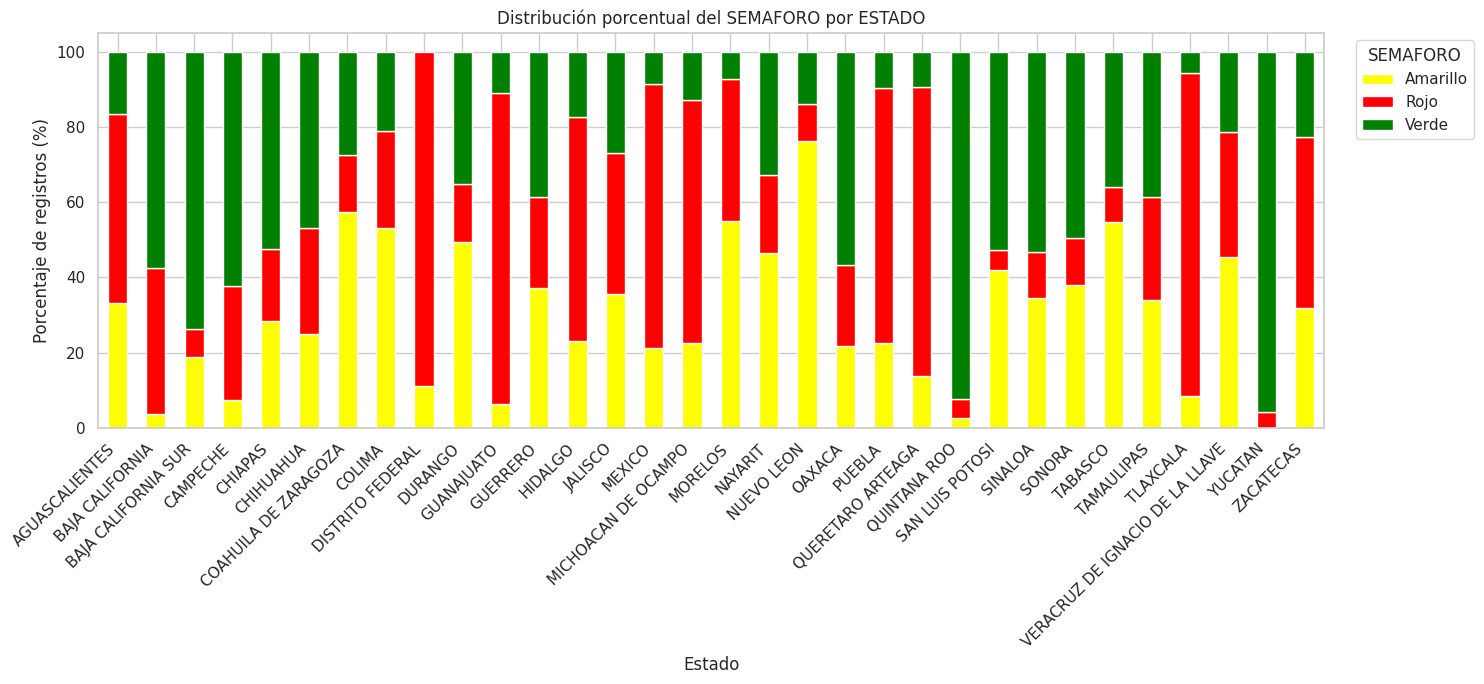

In [25]:
# Visualizamos la distribución porcentual del semáforo por estado.
tabla = pd.crosstab(
    df_crudo['ESTADO'],
    df_crudo['SEMAFORO'],
    normalize='index'
) * 100

# Crear gráfico
ax = tabla.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 7)
)

# Cambiar los colores de TODOS los segmentos
for container, categoria in zip(ax.containers, tabla.columns):

    if str(categoria).upper() == 'VERDE':
        color = 'green'

    elif str(categoria).upper() == 'AMARILLO':
        color = 'yellow'

    elif str(categoria).upper() == 'ROJO':
        color = 'red'

    else:
        color = 'gray'

    # Aplicar el color a todas las barras/segmentos
    for barra in container:
        barra.set_facecolor(color)

# Títulos
plt.title('Distribución porcentual del SEMAFORO por ESTADO')
plt.xlabel('Estado')
plt.ylabel('Porcentaje de registros (%)')
plt.xticks(rotation=45, ha='right')

plt.legend(
    title='SEMAFORO',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## 3. Análisis exploratorio (EDA (Análisis Exploratorio de Datos.))

OSEMN Explore: describe, sesgo, histogramas, boxplot e IQR; Pearson solo en calidad (no es input de K-means).

Rúbrica 2:
- a. Tendencia central: media y mediana (`describe` + `sesgo`).
- b. Dispersión: `std`, `min`, `max`, rango.
- c. Posición: cuartiles (25/50/75), IQR y outliers (boxplot).
- d. Correlaciones: Pearson en `cols_eda` (no entra a K-means).

In [26]:
# Seleccionamos las variables numéricas utilizadas en el EDA y las correlaciones.
cols_eda = [c for c in X_NUMERICAS if c in df.columns]
cols_corr = cols_eda
print(cols_eda)

['DBO_mg/L', 'DQO_mg/L', 'SST_mg/L', 'COLI_FEC_NMP_100mL', 'E_COLI_NMP_100mL', 'ENTEROC_NMP_100mL', 'OD_PORC', 'OD_PORC_SUP']


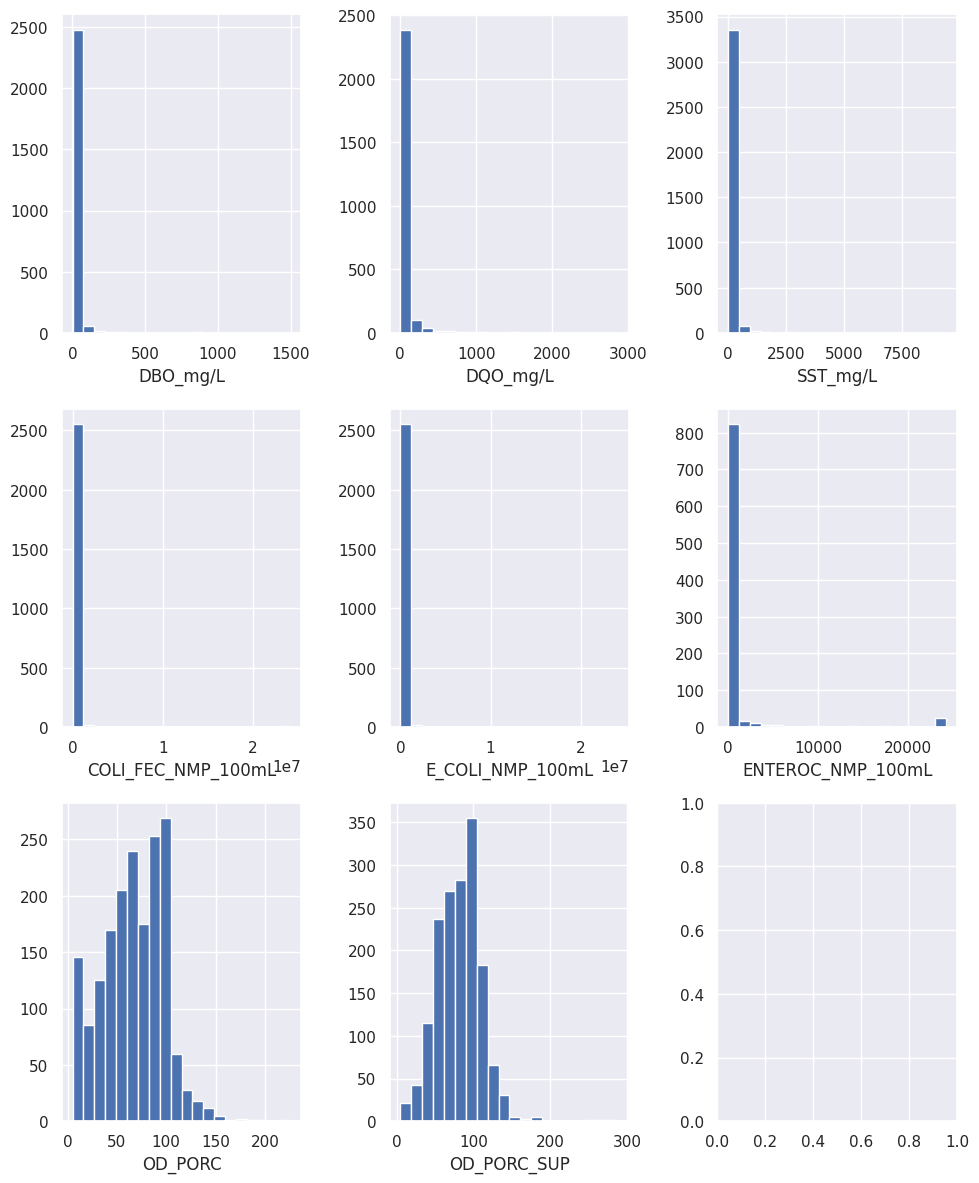

In [27]:
# Visualizamos la distribución de las variables numéricas seleccionadas.
sns.set(rc={"figure.figsize": (10, 12)})
fig, axes = plt.subplots(3, 3)
for k, col in enumerate(cols_eda):
    plt.subplot(3, 3, k + 1)
    plt.hist(df[col].dropna(), bins=20)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

In [28]:
# Resumimos las principales estadísticas descriptivas de las variables numéricas.
desc = df[cols_corr].describe(percentiles=[0.25, 0.5, 0.75]).T
desc["media"] = df[cols_corr].mean()
desc["mediana"] = df[cols_corr].median()
desc["rango"] = desc["max"] - desc["min"]
desc["desvi_estandar"] = df[cols_corr].std()
desc[["count", "media", "mediana", "desvi_estandar", "min", "25%", "50%", "75%", "max", "rango"]].round(2)

,count,media,mediana,desvi_estandar,min,25%,50%,75%,max,rango
DBO_mg/L,2581.0,16.41,2.63,65.25,1.0,1.00,2.63,10.00,1500.00,1499.00
DQO_mg/L,2581.0,63.25,27.01,150.23,5.0,11.87,27.01,57.00,2871.25,2866.25
SST_mg/L,3489.0,100.89,24.30,442.13,5.0,5.00,24.30,57.00,9430.00,9425.00
COLI_FEC_NMP_100mL,2582.0,95688.75,2400.00,1168887.30,1.5,342.00,2400.00,24000.00,24196000.00,24195998.50
E_COLI_NMP_100mL,2582.0,79337.48,424.00,1051334.13,1.5,40.00,424.00,6488.00,24196000.00,24195998.50
ENTEROC_NMP_100mL,904.0,1085.94,1.50,4306.11,1.5,1.50,1.50,63.00,24196.00,24194.50
OD_PORC,1797.0,66.53,68.30,31.99,5.0,44.30,68.30,91.60,226.10,221.10
OD_PORC_SUP,1619.0,81.41,84.10,28.68,5.0,61.20,84.10,99.95,289.00,284.00


In [29]:
# Calculamos y analizamos el sesgo de las variables numéricas.
sesgo = pd.DataFrame({
    "media": df[cols_eda].mean(),
    "mediana": df[cols_eda].median(),
})
sesgo["diferencia"] = sesgo["media"] - sesgo["mediana"]
sesgo["sesgo_relativo"] = (sesgo["diferencia"] / sesgo["mediana"].replace(0, np.nan)).round(2)
sesgo.sort_values("sesgo_relativo", ascending=False)

,media,mediana,diferencia,sesgo_relativo
ENTEROC_NMP_100mL,1085.939934,1.50,1084.439934,722.96
E_COLI_NMP_100mL,79337.475407,424.00,78913.475407,186.12
COLI_FEC_NMP_100mL,95688.745352,2400.00,93288.745352,38.87
DBO_mg/L,16.412246,2.63,13.782246,5.24
SST_mg/L,100.887038,24.30,76.587038,3.15
DQO_mg/L,63.250071,27.01,36.240071,1.34
OD_PORC,66.534224,68.30,-1.765776,-0.03
OD_PORC_SUP,81.413650,84.10,-2.686350,-0.03


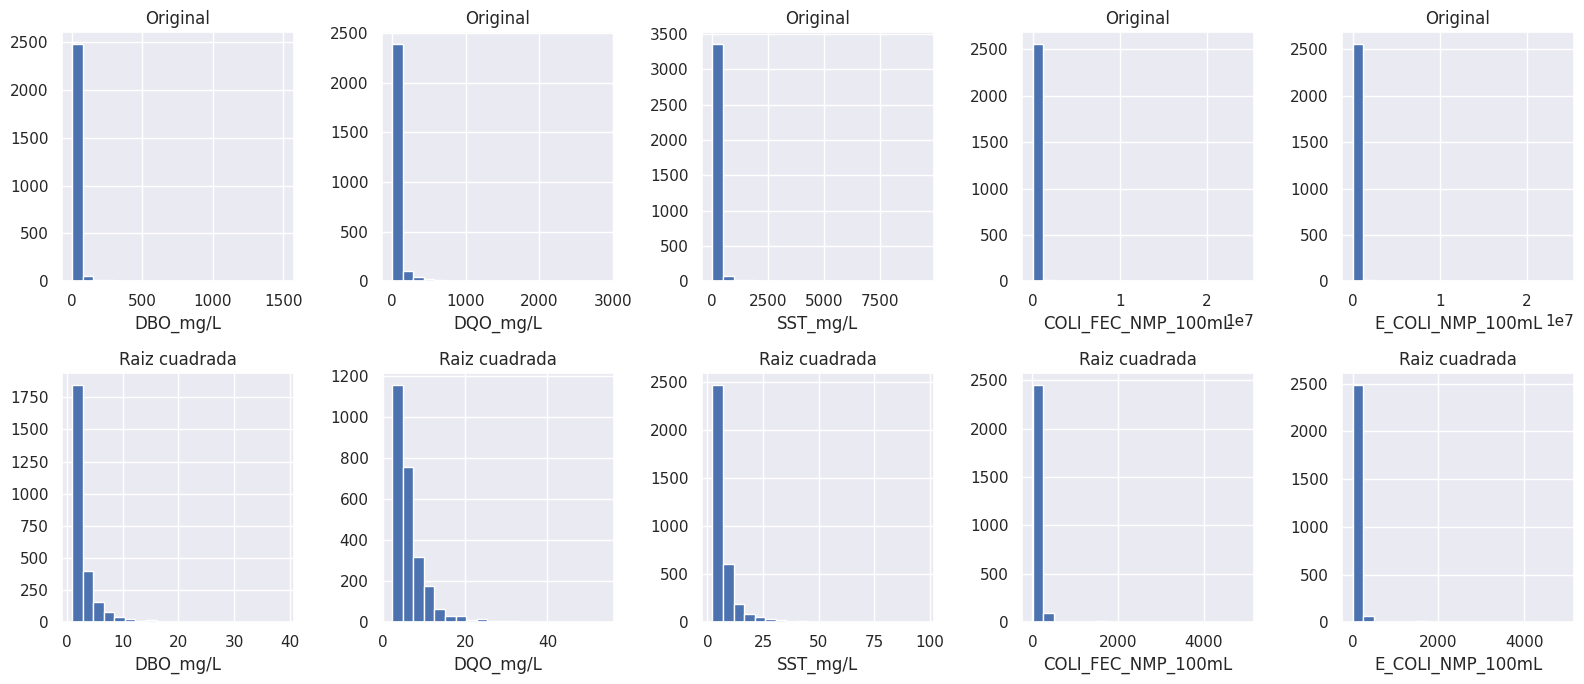

In [30]:
# Comparamos las distribuciones originales con sus transformaciones de raíz cuadrada.
cols_sesgo = [c for c in [
    "DBO_mg/L", "DQO_mg/L", "SST_mg/L",
    "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL",
] if c in df.columns]

sns.set(rc={"figure.figsize": (16, 7)})
fig, axes = plt.subplots(2, len(cols_sesgo))
for k, col in enumerate(cols_sesgo):
    tmp = df[col].dropna()
    tmp = tmp[tmp >= 0]
    plt.subplot(2, len(cols_sesgo), k + 1)
    plt.hist(tmp, bins=20)
    plt.xlabel(col)
    plt.title("Original")
    plt.subplot(2, len(cols_sesgo), k + 1 + len(cols_sesgo))
    plt.hist(np.sqrt(tmp), bins=20)
    plt.xlabel(col)
    plt.title("Raiz cuadrada")
plt.tight_layout()
plt.show()

In [31]:
# Calcula y muestra los outliers de las variables numéricas utilizando el método del rango intercuartílico (IQR).
def contar_outliers_iqr(serie):
    datos = serie.dropna()
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    iqr = q3 - q1
    inf, sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((datos < inf) | (datos > sup)).sum())
    return n_out, inf, sup

filas = []
for col in cols_eda:
    n_out, inf, sup = contar_outliers_iqr(df[col])
    n_ok = df[col].notna().sum()
    filas.append({
        "variable": col,
        "n_validos": n_ok,
        "outliers": n_out,
        "porcentaje": round(100 * n_out / n_ok, 1) if n_ok else 0,
        "limite_inf": inf,
        "limite_sup": sup,
    })
pd.DataFrame(filas)

,variable,n_validos,outliers,porcentaje,limite_inf,limite_sup
0,DBO_mg/L,2581,328,12.7,-12.500,23.500
1,DQO_mg/L,2581,263,10.2,-55.825,124.695
2,SST_mg/L,3489,420,12.0,-73.000,135.000
3,COLI_FEC_NMP_100mL,2582,133,5.2,-35145.000,59487.000
4,E_COLI_NMP_100mL,2582,505,19.6,-9632.000,16160.000
5,ENTEROC_NMP_100mL,904,167,18.5,-90.750,155.250
6,OD_PORC,1797,6,0.3,-26.650,162.550
7,OD_PORC_SUP,1619,12,0.7,3.075,158.075


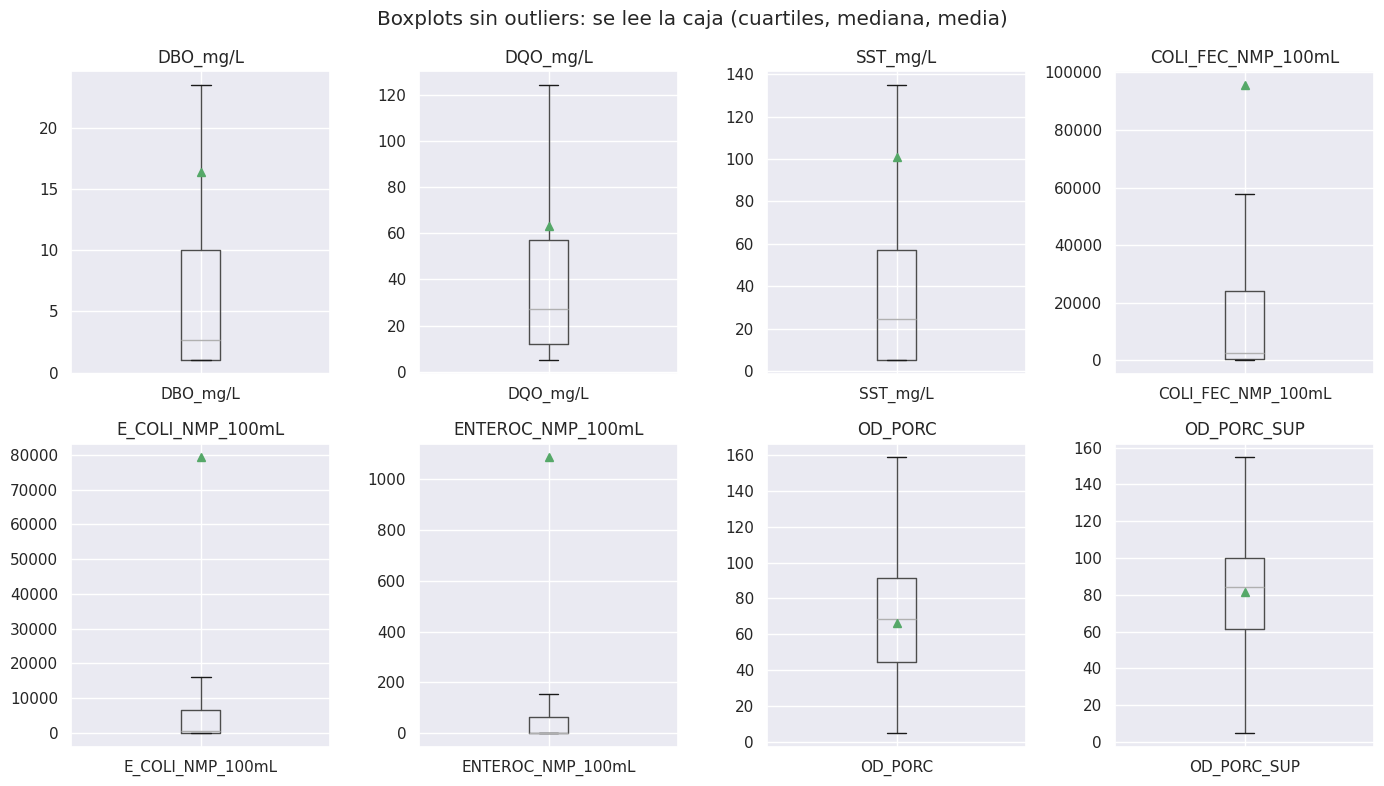

In [32]:
# Visualizamos boxplots sin valores atípicos para comparar las variables.
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for ax, col in zip(axes.ravel(), cols_eda):
    df[[col]].boxplot(ax=ax, showmeans=True, showfliers=False)
    ax.set_title(col)
    ax.set_ylabel("")
fig.suptitle("Boxplots sin outliers: se lee la caja (cuartiles, mediana, media)")
plt.tight_layout()
plt.show()

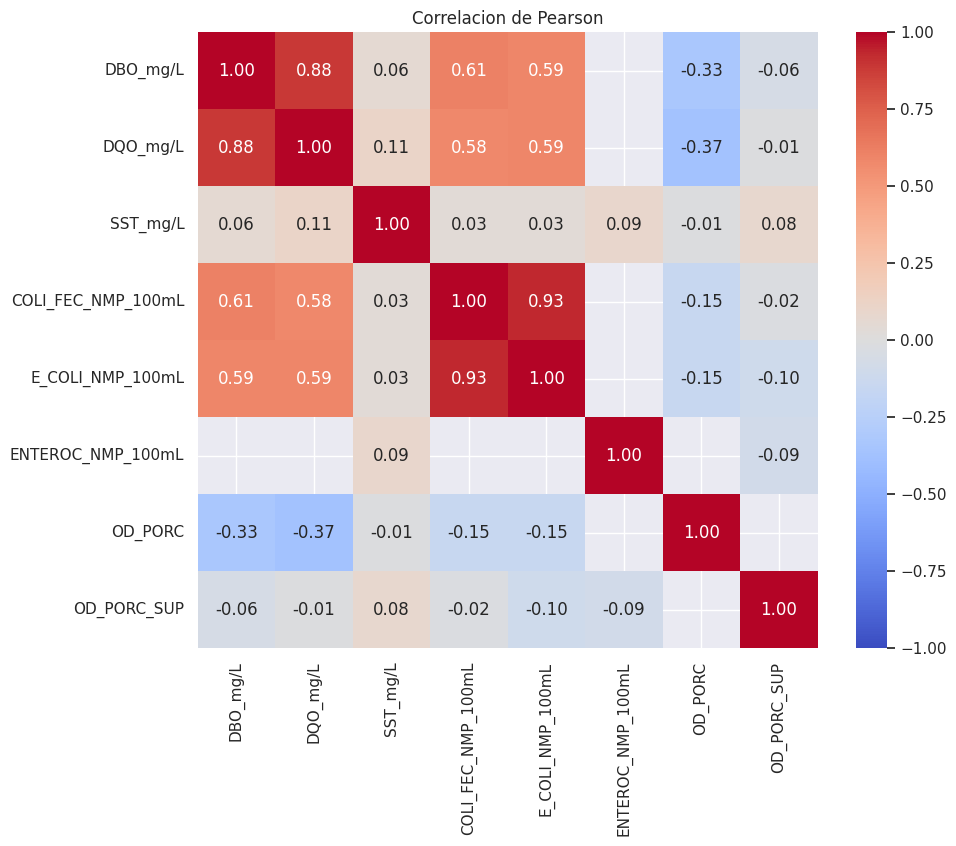

In [33]:
# Calculamos y visualizamos la matriz de correlación de Pearson.
corr = df[cols_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlacion de Pearson")
plt.show()

### En cúal estado de México le gustaría comprar casa si su prioridad fuera la calidad del agua?

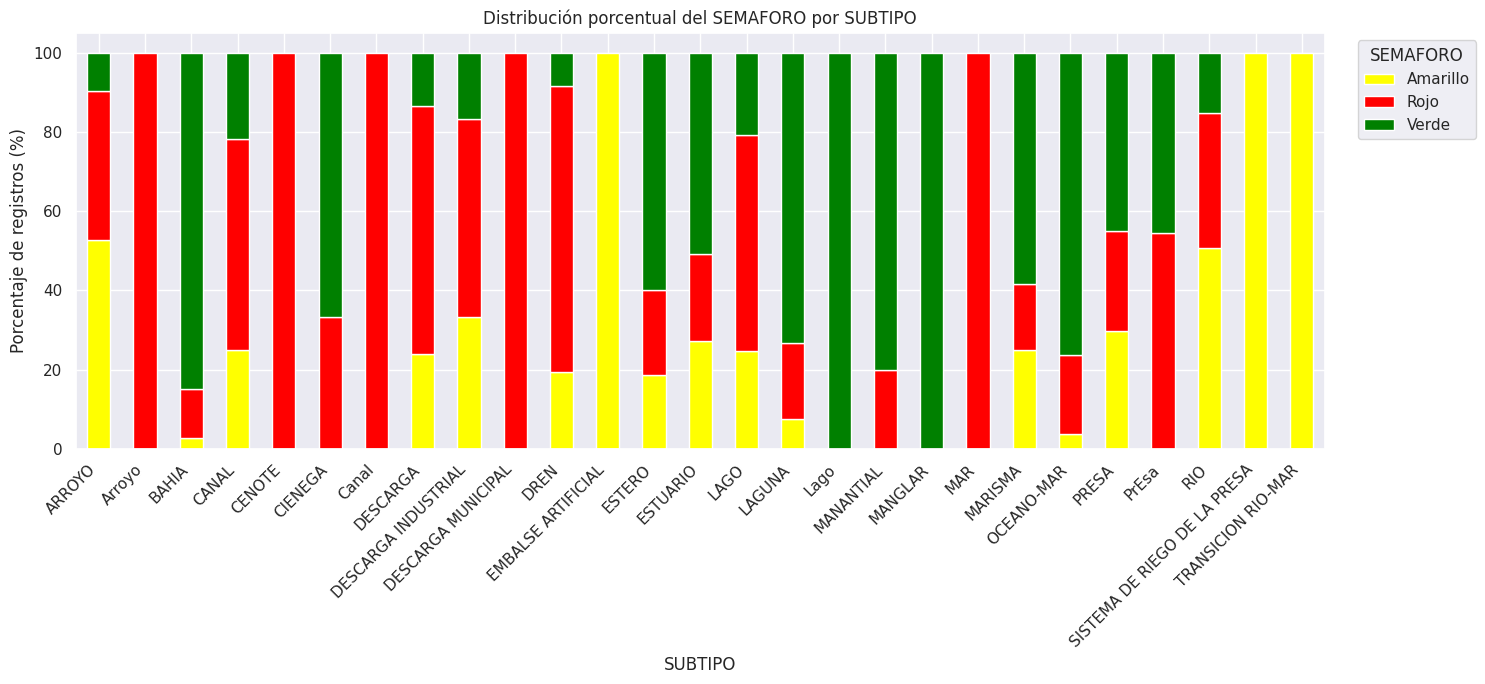

In [34]:
# Visualizamos la distribución porcentual del semáforo por subtipo.
tabla = pd.crosstab(
    df_crudo['SUBTIPO'],
    df_crudo['SEMAFORO'],
    normalize='index'
) * 100

# Crear gráfico de barras apiladas
ax = tabla.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 7)
)

# Colores correctos para cada categoría del semáforo
for container, categoria in zip(ax.containers, tabla.columns):

    if str(categoria).upper() == 'VERDE':
        color = 'green'

    elif str(categoria).upper() == 'AMARILLO':
        color = 'yellow'

    elif str(categoria).upper() == 'ROJO':
        color = 'red'

    else:
        color = 'gray'

    # Aplicar color a todos los segmentos
    for barra in container:
        barra.set_facecolor(color)

plt.title('Distribución porcentual del SEMAFORO por SUBTIPO')
plt.xlabel('SUBTIPO')
plt.ylabel('Porcentaje de registros (%)')
plt.xticks(rotation=45, ha='right')

plt.legend(
    title='SEMAFORO',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Basado en el subtipo del agua, de qué repositorio de agua bebería y de cúal no bebería?

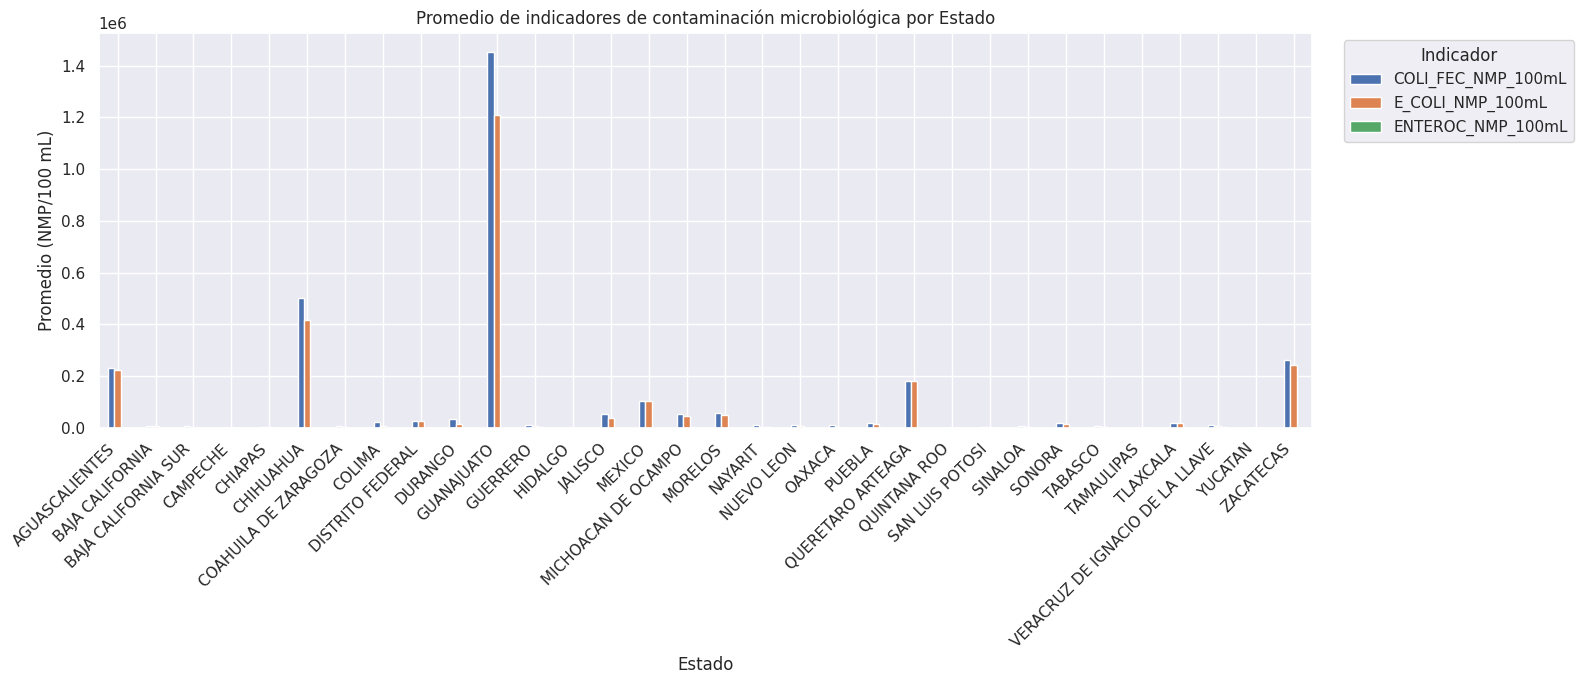

In [35]:
# Comparamos los indicadores microbiológicos promedio entre los estados.
columnas_micro = [
    'COLI_FEC_NMP_100mL',
    'E_COLI_NMP_100mL',
    'ENTEROC_NMP_100mL'
]

# Calcular el promedio por ESTADO
promedios = df.groupby('ESTADO')[columnas_micro].mean()

# Crear gráfico
ax = promedios.plot(
    kind='bar',
    figsize=(16, 7)
)

plt.title('Promedio de indicadores de contaminación microbiológica por Estado')
plt.xlabel('Estado')
plt.ylabel('Promedio (NMP/100 mL)')
plt.xticks(rotation=45, ha='right')

plt.legend(
    title='Indicador',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

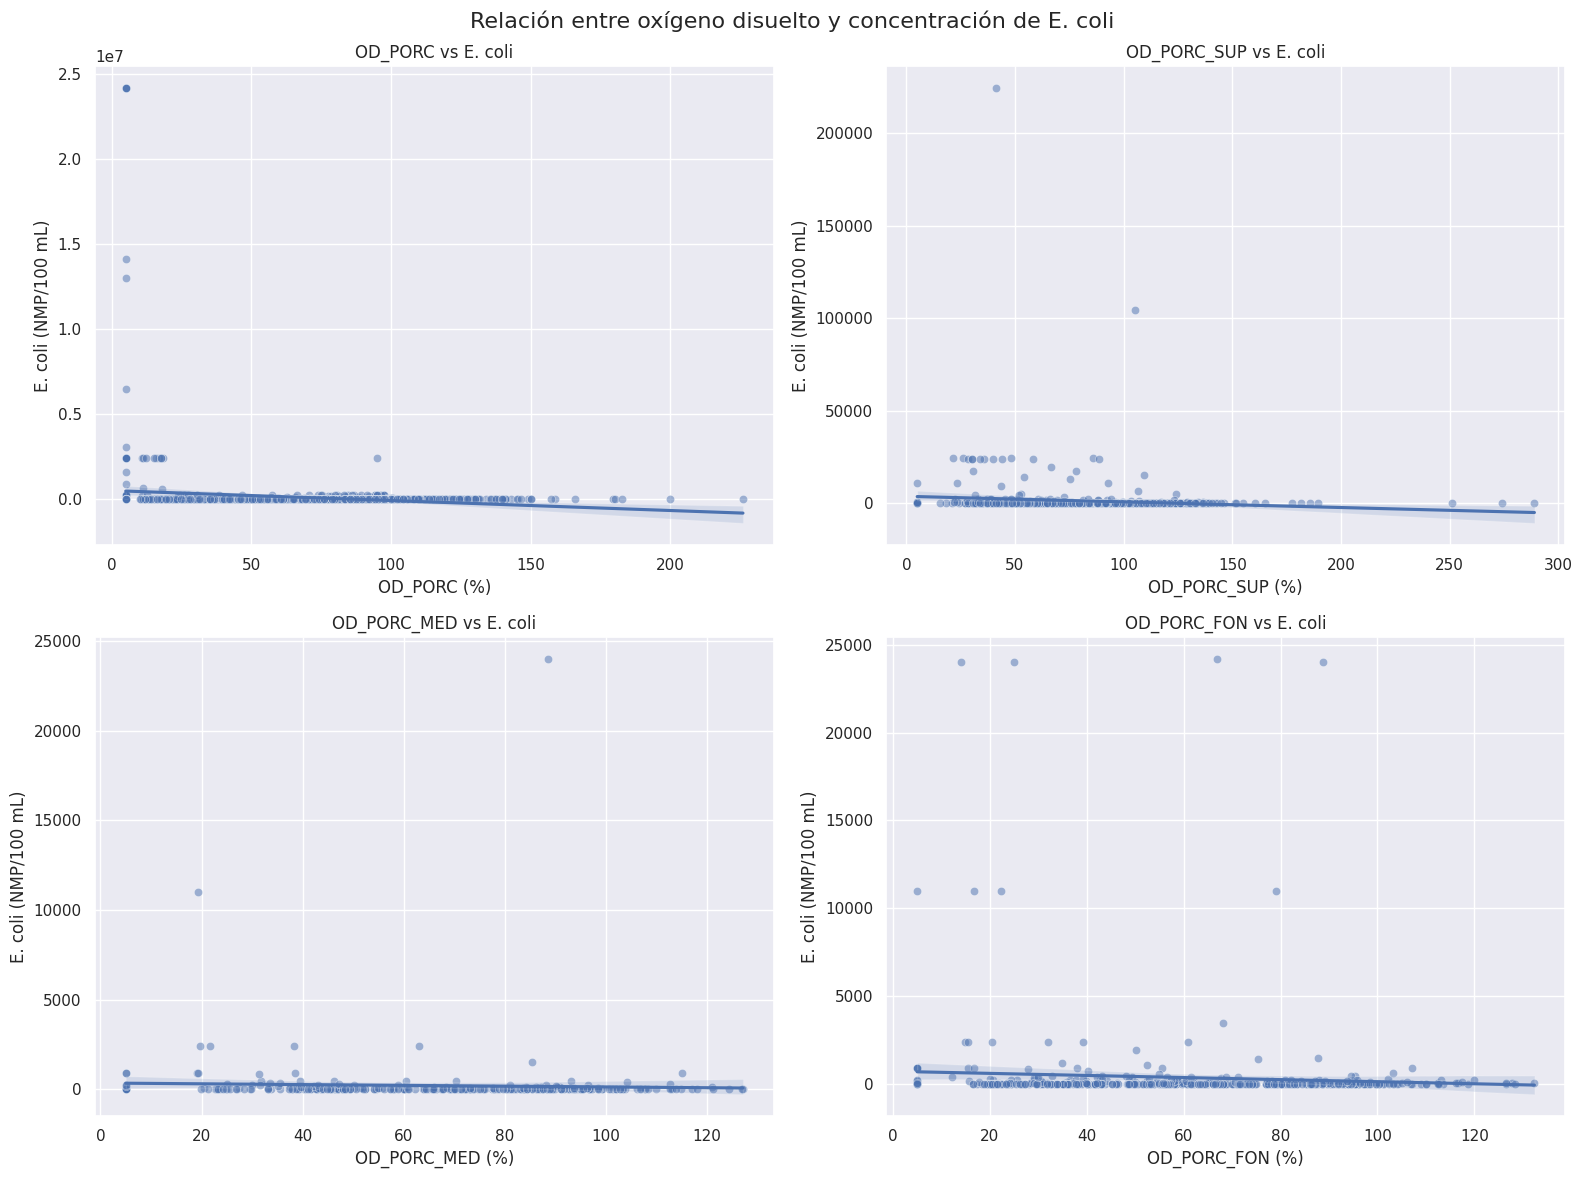

In [36]:
# Comparamos las mediciones de oxígeno disuelto mediante diagramas de caja.
columnas_oxigeno = [
    'OD_PORC',
    'OD_PORC_SUP',
    'OD_PORC_MED',
    'OD_PORC_FON'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, columna in zip(axes.flatten(), columnas_oxigeno):

    # Eliminar registros sin datos
    datos = df[[columna, 'E_COLI_NMP_100mL']].dropna()

    # Gráfico de dispersión
    sns.scatterplot(
        data=datos,
        x=columna,
        y='E_COLI_NMP_100mL',
        ax=ax,
        alpha=0.5
    )

    # Línea de tendencia
    sns.regplot(
        data=datos,
        x=columna,
        y='E_COLI_NMP_100mL',
        scatter=False,
        ax=ax
    )

    ax.set_title(f'{columna} vs E. coli')
    ax.set_xlabel(f'{columna} (%)')
    ax.set_ylabel('E. coli (NMP/100 mL)')

plt.suptitle(
    'Relación entre oxígeno disuelto y concentración de E. coli',
    fontsize=16
)

plt.tight_layout()
plt.show()

Existe una relación aparente, aunque no siempre lineal ni fuerte, entre el oxígeno disuelto y la concentración de E. coli. En términos generales, sí existe una relación en el hecho de que a mayor oxígeno disuelto (especialmente en el porcentaje general y en superficie), tiende a haber una menor concentración de E. coli. Esto es consistente con la idea de que un ambiente con buen oxígeno disuelto es más saludable y menos propicio para la proliferación de bacterias fecales, aunque no es el único factor determinante. Las mediciones en la zona media y el fondo muestran una menor correlación, lo que podría deberse a la estabilidad de E. coli en estas capas o a que otras condiciones influyen más en su presencia a esas profundidades.

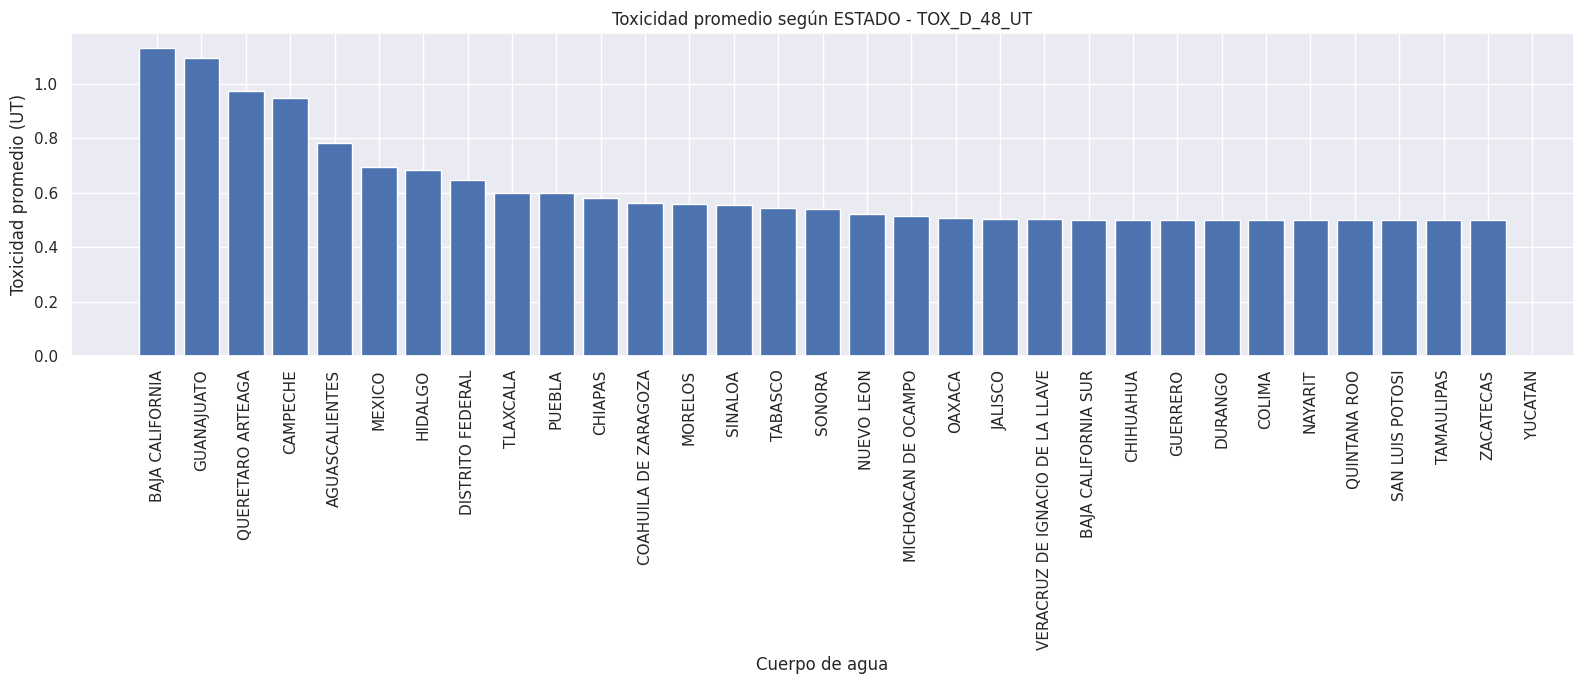

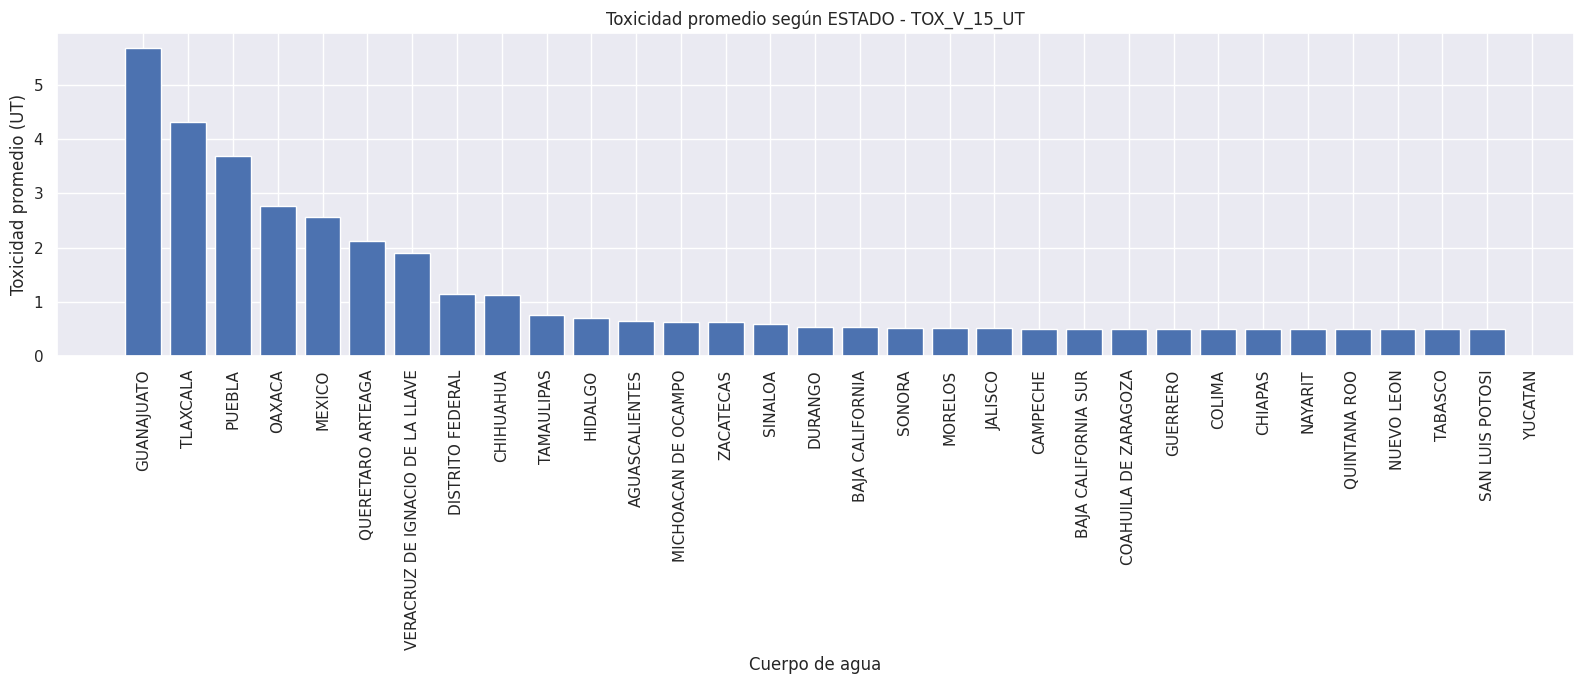

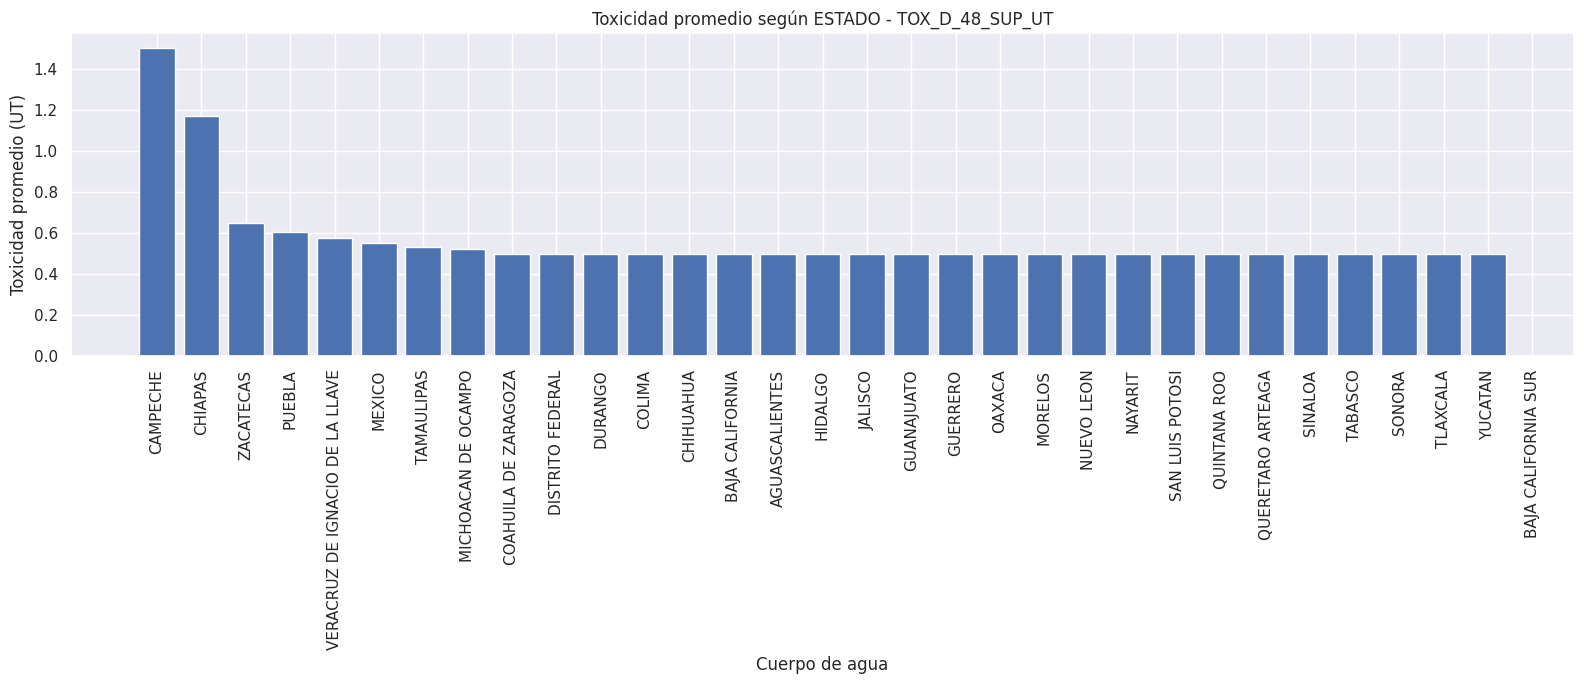

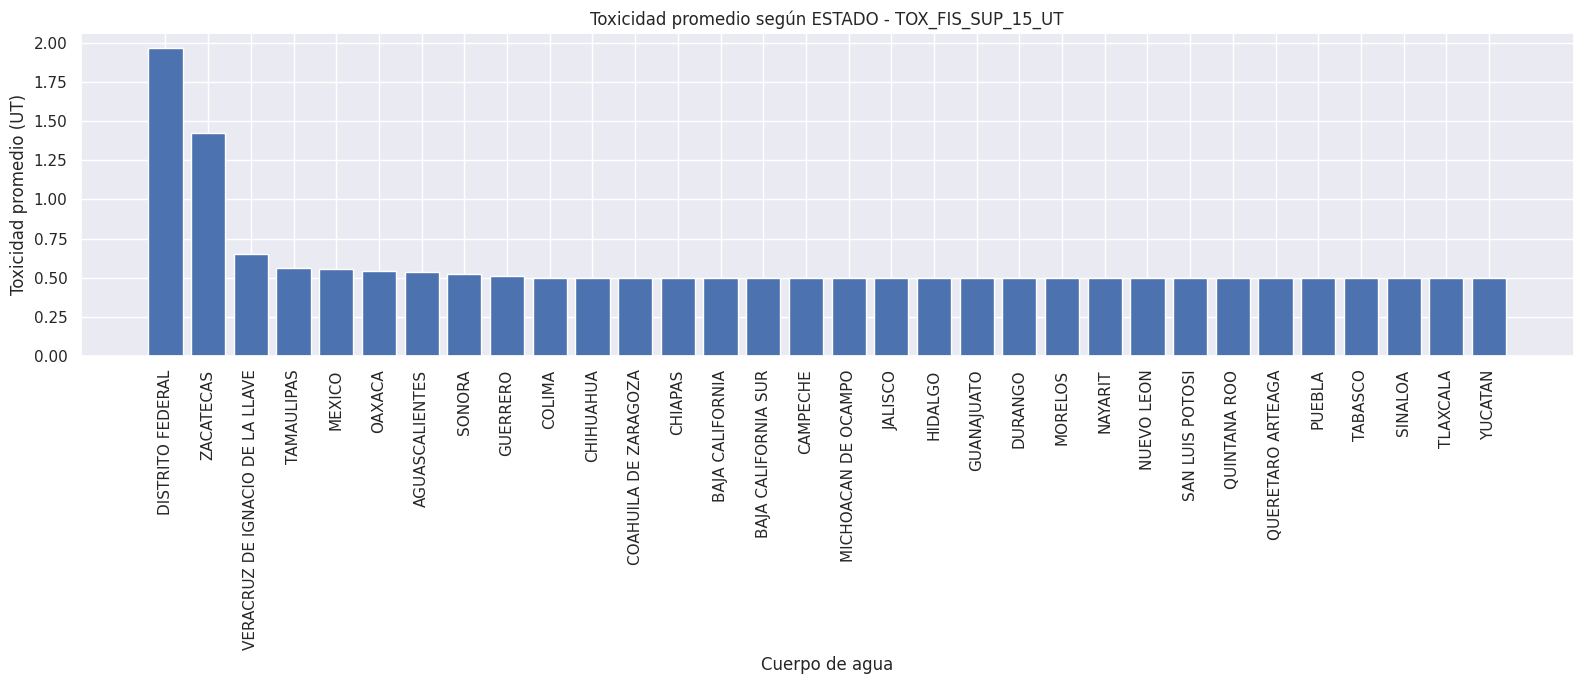

In [37]:
# Analizamos las variables de toxicidad disponibles por grupo.
columnas_toxicidad = [
    'TOX_D_48_UT',
    'TOX_V_15_UT',
    'TOX_D_48_SUP_UT',
    'TOX_FIS_SUP_15_UT'
]

for columna in columnas_toxicidad:

    promedio = (
        df
        .groupby('ESTADO')[columna]
        .mean()
        .reset_index()
        .sort_values(columna, ascending=False)
    )

    plt.figure(figsize=(16, 7))

    plt.bar(
        promedio['ESTADO'],
        promedio[columna]
    )

    plt.title(f'Toxicidad promedio según ESTADO - {columna}')
    plt.xlabel('Cuerpo de agua')
    plt.ylabel('Toxicidad promedio (UT)')

    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

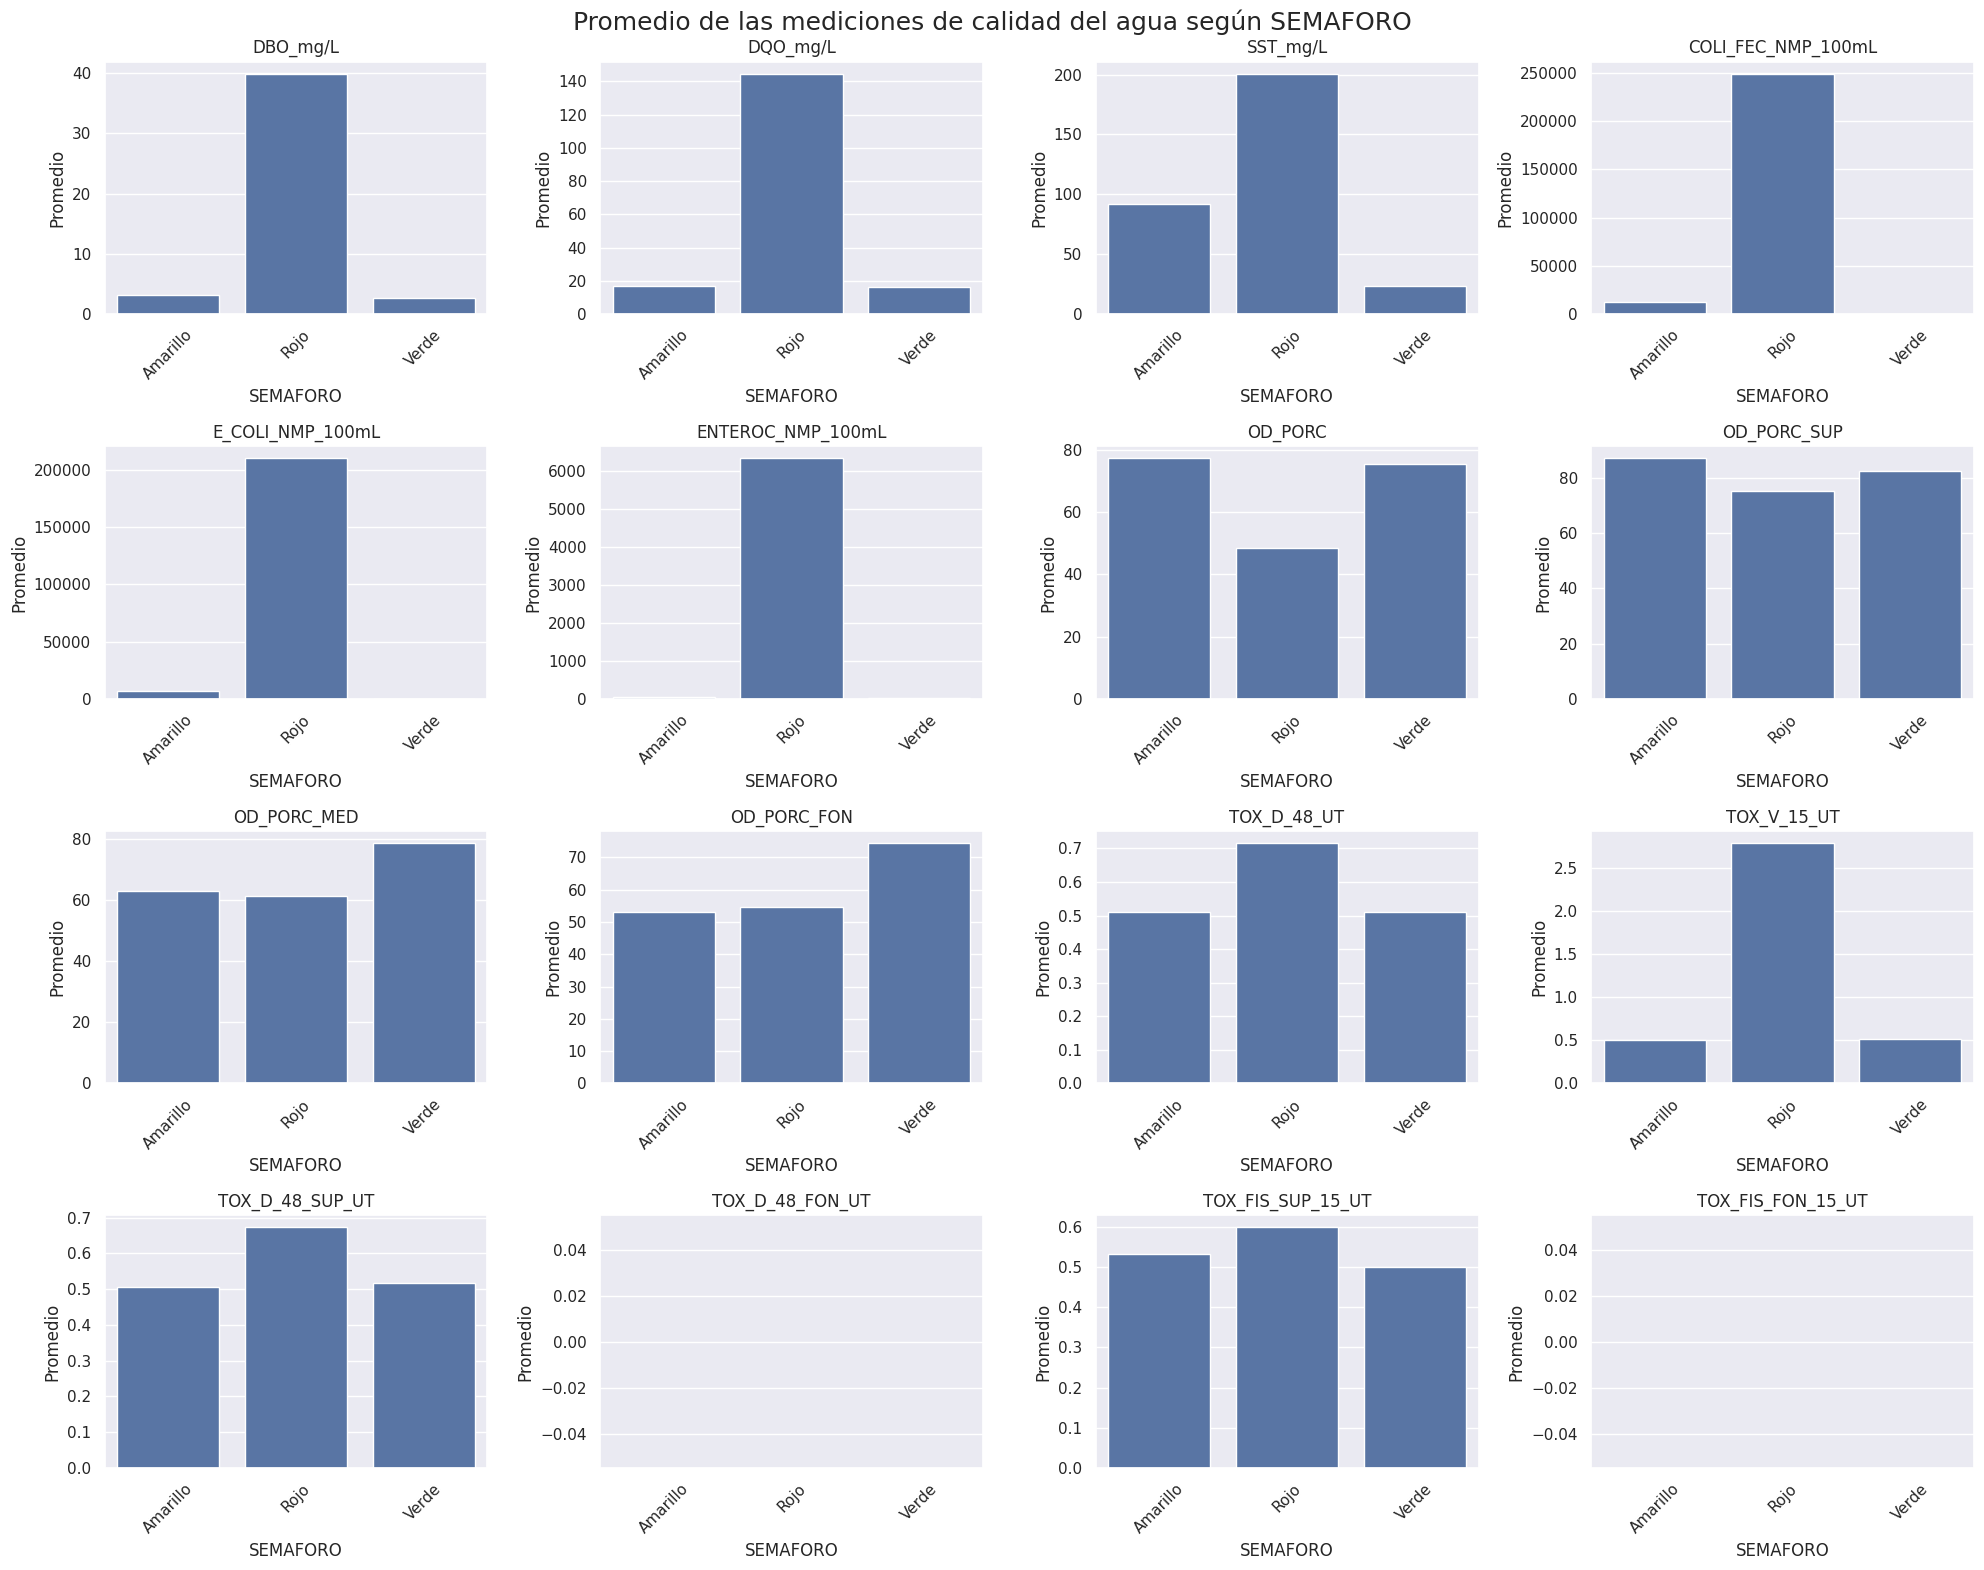

In [38]:
# Visualizamos la relación de cada medición con la clasificación del semáforo.
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
columnas_medicion = [ 'DBO_mg/L', 'DQO_mg/L', 'SST_mg/L', 'COLI_FEC_NMP_100mL',
                      'E_COLI_NMP_100mL', 'ENTEROC_NMP_100mL', 'OD_PORC',
                      'OD_PORC_SUP', 'OD_PORC_MED', 'OD_PORC_FON', 'TOX_D_48_UT',
                      'TOX_V_15_UT', 'TOX_D_48_SUP_UT', 'TOX_D_48_FON_UT',
                      'TOX_FIS_SUP_15_UT', 'TOX_FIS_FON_15_UT' ]
for ax, columna in zip(axes.flatten(), columnas_medicion):

    promedio = df.groupby('SEMAFORO')[columna].mean().reset_index()

    sns.barplot(
        data=promedio,
        x='SEMAFORO',
        y=columna,
        ax=ax
    )

    ax.set_title(columna)
    ax.set_xlabel('SEMAFORO')
    ax.set_ylabel('Promedio')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Promedio de las mediciones de calidad del agua según SEMAFORO',
    fontsize=18
)

plt.tight_layout()
plt.show()

### Variables categóricas como columnas binarias

Para analizar categorías sin asignarles un orden artificial, se aplica codificación *one-hot* a `GRUPO` y `SEMAFORO`. Cada categoría se convierte en una columna cuyo valor es `1` cuando el registro pertenece a ella y `0` cuando no pertenece.

Como estas columnas solo contienen ceros y unos, su promedio multiplicado por 100 representa directamente un porcentaje. Por ejemplo, el promedio de `SEMAFORO_Rojo` dentro de cada `GRUPO` corresponde al porcentaje de sitios rojos de ese grupo.

> `SUBTIPO` no se incluye todavía porque contiene variantes de escritura que deben normalizarse antes de codificarlo.

In [39]:
# Convertimos GRUPO y SEMAFORO en columnas binarias de 0 y 1.
columnas_categoricas = ["GRUPO", Y]
df_categoricas_01 = pd.get_dummies(
    df[columnas_categoricas],
    prefix=columnas_categoricas,
    dtype=int,
)

print("Dimensiones:", df_categoricas_01.shape)
display(df_categoricas_01.head())

Dimensiones: (3493, 6)


,GRUPO_COSTERO,GRUPO_LENTICO,GRUPO_LOTICO,SEMAFORO_Amarillo,SEMAFORO_Rojo,SEMAFORO_Verde
0,0,1,0,0,1,0
1,1,0,0,0,0,1
2,1,0,0,0,0,1
3,1,0,0,0,0,1
4,1,0,0,0,0,1


In [40]:
# Calculamos los porcentajes del semáforo dentro de cada grupo.
columnas_semaforo_01 = [
    columna for columna in df_categoricas_01.columns
    if columna.startswith(f"{Y}_")
]

porcentaje_semaforo_grupo = (
    pd.concat([df[["GRUPO"]], df_categoricas_01[columnas_semaforo_01]], axis=1)
    .groupby("GRUPO")[columnas_semaforo_01]
    .mean()
    .mul(100)
    .round(1)
    .rename(columns=lambda columna: columna.replace(f"{Y}_", "% "))
)
porcentaje_semaforo_grupo.insert(0, "sitios", df.groupby("GRUPO").size())
porcentaje_semaforo_grupo

,sitios,% Amarillo,% Rojo,% Verde
GRUPO,,,,
COSTERO,988,8.2,17.0,74.8
LENTICO,733,27.0,36.0,37.0
LOTICO,1772,48.3,37.2,14.5


#### Interpretación

El porcentaje de sitios rojos cambia según el grupo de agua superficial: `COSTERO` presenta **17.0 %**, `LENTICO` **36.0 %** y `LOTICO` **37.2 %**. El grupo costero también concentra el mayor porcentaje verde (**74.8 %**), mientras que el grupo lótico presenta el menor (**14.5 %**).

Este resultado es descriptivo: muestra cómo se distribuye el semáforo entre los sitios monitoreados de cada grupo, pero no demuestra que el tipo de cuerpo de agua cause esas diferencias. Además, los grupos no comparten exactamente las mismas mediciones disponibles.

### Sugerencias para discutir con el equipo

Estas observaciones no eliminan el análisis existente; proponen ajustar su alcance antes de la entrega final:

- **Pregunta sobre vivienda:** cambiar *“¿En cuál estado de México le gustaría comprar casa si su prioridad fuera la calidad del agua?”* por *“¿Cómo varían los indicadores de calidad del agua superficial entre los sitios monitoreados de cada estado?”*.
- **Pregunta sobre consumo:** cambiar cualquier referencia a *“¿De cuál agua bebería?”* por *“¿Cómo cambia la clasificación de calidad entre los diferentes subtipos de cuerpos de agua superficial?”*.
- **Aclaración metodológica propuesta:** *“Estos resultados corresponden a sitios de monitoreo de aguas superficiales durante 2020. No representan directamente la calidad del agua potable domiciliaria y, por sí solos, no permiten recomendar un estado para vivir ni determinar si el agua puede consumirse.”*

**Pendiente de decisión del equipo:** conservar los gráficos y reemplazar únicamente las preguntas e interpretaciones que exceden lo que los datos permiten concluir.

## 4. Preparar los datos (Pipeline del Laboratorio 1)
OSEMN Scrub (Pipeline Lab 1): mediana + raíz + MinMax en variables sesgadas y mediana + MinMax en las demás → `X_prep`. No entra a K-means.

Cada variable pasa por una sola rama del `ColumnTransformer`, por lo que la matriz final conserva las ocho variables sin duplicarlas.

Este bloque es una demostración didáctica de preparación de **calidad** del Laboratorio 1. Como los faltantes dependen fuertemente del tipo de agua (`GRUPO`), la matriz imputada **NO se usa para K-means ni para sustentar las conclusiones**.
K-means usa solo latitud y longitud originales, sin imputar ni escalar.
Como ambas coordenadas están expresadas en grados, se conservan sus valores originales. La inercia se calcula en grados cuadrados y no se interpreta en kilómetros.

In [41]:
# Cada variable debe pasar por una sola rama del ColumnTransformer.
cols_sin_sesgo = [col for col in cols_eda if col not in cols_sesgo]

pipeline_sesgo = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="median")),
    ("raiz", FunctionTransformer(np.sqrt)),
    ("escalar", MinMaxScaler(feature_range=(1, 2))),
])

pipeline_sin_sesgo = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", MinMaxScaler(feature_range=(1, 2))),
])

columnasTransformer = ColumnTransformer(
    transformers=[
        ("con_sesgo", pipeline_sesgo, cols_sesgo),
        ("sin_sesgo", pipeline_sin_sesgo, cols_sin_sesgo),
    ],
    remainder="drop",
)

X_prep = columnasTransformer.fit_transform(df[cols_eda])
columnas_prep = cols_sesgo + cols_sin_sesgo
print("Matriz preparada (calidad, NO se usa en K-means):", X_prep.shape)
print("Valores faltantes en X_prep:", int(np.isnan(X_prep).sum()))
pd.DataFrame(X_prep, columns=columnas_prep).describe().round(3)

Matriz preparada (calidad, NO se usa en K-means): (3493, 8)
Valores faltantes en X_prep: 0


,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,ENTEROC_NMP_100mL,OD_PORC,OD_PORC_SUP
count,3493.000,3493.000,3493.000,3493.000,3493.000,3493.000,3493.000,3493.000
mean,1.037,1.074,1.049,1.018,1.013,1.012,1.282,1.274
std,0.070,0.081,0.077,0.051,0.048,0.093,0.104,0.069
min,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
25%,1.000,1.036,1.000,1.006,1.002,1.000,1.282,1.279
50%,1.016,1.058,1.028,1.010,1.004,1.000,1.286,1.279
75%,1.042,1.084,1.056,1.021,1.010,1.000,1.291,1.279
max,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000


In [42]:
# Preparamos las coordenadas originales utilizadas por K-means.
X_geo = df[COLS_GEO].copy()
print(X_geo.shape)
print("K-means usará latitud y longitud originales, sin escalado.")
print("La inercia se calcula en grados cuadrados; no se interpreta en kilómetros.")
print("Rango lon:", float(X_geo["LONGITUD"].min()), float(X_geo["LONGITUD"].max()))
print("Rango lat:", float(X_geo["LATITUD"].min()), float(X_geo["LATITUD"].max()))

(3493, 2)
K-means usará latitud y longitud originales, sin escalado.
La inercia se calcula en grados cuadrados; no se interpreta en kilómetros.
Rango lon: -117.12403 -86.73215
Rango lat: 14.53491 32.7065


## 5. Modelado geográfico con K-means

OSEMN Model: se agrupan los sitios mediante sus coordenadas originales y después se compara la distribución del semáforo entre las regiones obtenidas.

In [43]:
# Importamos las herramientas adicionales para el análisis geográfico y estadístico.
import folium
from scipy.stats import chi2_contingency
from sklearn.metrics import silhouette_samples
from shapely.geometry import MultiPoint

SEMILLA = 42
ORDEN_SEMAFORO = ["Verde", "Amarillo", "Rojo"]
COLORES_CLUSTER = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
AZUL, TINTA = "#2a78d6", "#0b0b0b"
# Opcional: geojson con los estados para dibujar el contorno de México en el mapa estático.
RUTA_ESTADOS = "https://raw.githubusercontent.com/marvinjc/proyecto_final_CD/main/mexico_estados.geojson"
RUTA_SALIDAS = Path("salidas"); RUTA_SALIDAS.mkdir(exist_ok=True)

X = df[COLS_GEO].to_numpy()
df["SEMAFORO_NUM"] = df[Y].map({"Verde": 0, "Amarillo": 1, "Rojo": 2})
print(X.shape, "| nulos:", np.isnan(X).sum())

(3493, 2) | nulos: 0


In [44]:
# Calculamos la inercia y el silhouette para distintos valores de k.
valores_k = range(2, 13)
inercia, silueta = [], []
for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X)
    inercia.append(modelo.inertia_)
    silueta.append(silhouette_score(X, modelo.labels_))
eleccion_k = pd.DataFrame({"inercia": inercia, "silhouette": silueta}, index=pd.Index(valores_k, name="k")).round(3)

# Codo: punto más alejado de la recta que une el primer y el último valor de inercia (ambos ejes normalizados a [0, 1]).
x_n = (np.array(valores_k) - valores_k[0]) / (valores_k[-1] - valores_k[0])
y_n = (np.array(inercia) - inercia[-1]) / (inercia[0] - inercia[-1])
K_CODO = int(valores_k[np.argmax((1 - x_n) - y_n)])
print("Codo de la inercia: k =", K_CODO, "| Mejor silhouette: k =", eleccion_k["silhouette"].idxmax())
eleccion_k.T

Codo de la inercia: k = 4 | Mejor silhouette: k = 2


k,2,3,4,5,6,7,8,9,10,11,12
inercia,86050.400,47179.937,35198.214,27563.492,20416.876,15702.252,13391.277,11562.657,9990.603,8994.157,8237.535
silhouette,0.503,0.465,0.410,0.447,0.461,0.470,0.447,0.436,0.425,0.420,0.428


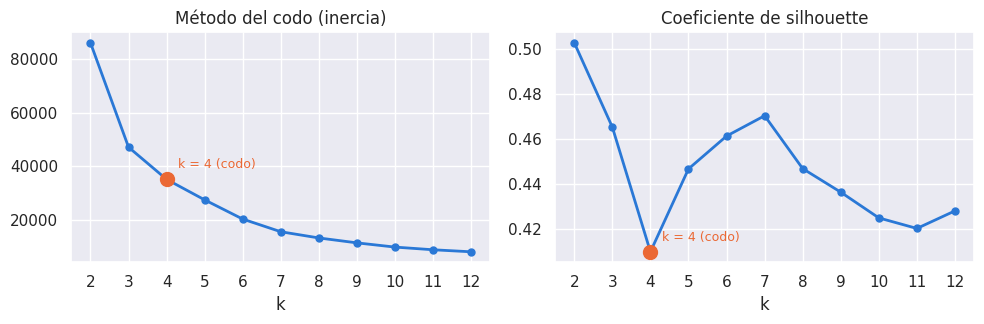

In [45]:
# Visualizamos el método del codo y el coeficiente silhouette.
K = 4  # k elegido: coincide con el codo (ver texto siguiente)
fig, (eje1, eje2) = plt.subplots(1, 2, figsize=(10, 3.4))
for eje, serie, titulo in [(eje1, inercia, "Método del codo (inercia)"), (eje2, silueta, "Coeficiente de silhouette")]:
    eje.plot(list(valores_k), serie, color=AZUL, linewidth=2, marker="o", markersize=5)
    eje.plot(K, serie[K - 2], marker="o", markersize=10, color="#eb6834", zorder=3)
    eje.annotate(f"k = {K} (codo)", (K, serie[K - 2]), textcoords="offset points", xytext=(8, 8), fontsize=9, color="#eb6834")
    eje.set_title(titulo); eje.set_xlabel("k"); eje.set_xticks(list(valores_k))
fig.tight_layout()
fig.savefig(RUTA_SALIDAS / "codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

### Sugerencia para discutir con el equipo: elección de `k`

Los dos criterios evaluados no responden exactamente a la misma pregunta:

- **Silhouette favorece `k=2` (`0.503`)**: produce la separación matemática más clara, pero divide el país en solo dos regiones muy amplias.
- **El método del codo favorece `k=4`**: la reducción de la inercia empieza a perder intensidad a partir de cuatro grupos. Su silhouette (`0.410`) es menor, pero permite representar cuatro regiones geográficas más detalladas e interpretables: Noroeste, Occidente-Norte, Centro-Golfo y Sur-Península.

**Redacción propuesta para el informe:**

> Se seleccionó `k=4` porque coincide con el punto de codo de la inercia y ofrece una división regional útil para comparar la calidad del agua. Aunque `k=2` obtiene el mayor coeficiente de silhouette, sus dos grupos resultan demasiado generales para el objetivo geográfico del proyecto. Por tanto, `k=4` se adopta como un equilibrio entre separación de los grupos e interpretación regional; no se afirma que sea la única solución posible ni la mejor según todos los criterios.

**Pendiente de decisión del equipo:** confirmar si se mantiene `k=4` por interpretabilidad o si se desea mostrar también el resultado con `k=2` como análisis de sensibilidad.

In [46]:
# Ajustamos K-means y asignamos una región a cada sitio.
kmeans = KMeans(n_clusters=K, n_init=10, random_state=SEMILLA).fit(X)
print(f"Convergió en {kmeans.n_iter_} iteraciones | inercia = {kmeans.inertia_:,.0f} | silhouette = {silhouette_score(X, kmeans.labels_):.3f}")

# Se renumeran los clusters de oeste a este para que el número tenga un significado estable.
orden = np.argsort(kmeans.cluster_centers_[:, 0])
nuevo_numero = {viejo: nuevo + 1 for nuevo, viejo in enumerate(orden)}
df["CLUSTER"] = pd.Series(kmeans.labels_, index=df.index).map(nuevo_numero)
centroides = pd.DataFrame(kmeans.cluster_centers_[orden], columns=["LONGITUD", "LATITUD"], index=pd.RangeIndex(1, K + 1, name="CLUSTER"))

NOMBRES = {1: "Noroeste", 2: "Occidente-Norte", 3: "Centro-Golfo", 4: "Sur-Península"}

# Radio medio: distancia de cada sitio a su centroide, en km (1° de latitud ≈ 111 km; 1° de longitud ≈ 111·cos(lat) km).
dif = df[COLS_GEO].to_numpy() - centroides.loc[df["CLUSTER"]].to_numpy()
df["DIST_CENTROIDE_KM"] = np.hypot(dif[:, 0] * 111 * np.cos(np.radians(df["LATITUD"])), dif[:, 1] * 111)
df["SILHOUETTE"] = silhouette_samples(X, kmeans.labels_)

resumen = centroides.round(2).assign(
    region=pd.Series(NOMBRES),
    sitios=df["CLUSTER"].value_counts().sort_index(),
    pct_sitios=df["CLUSTER"].value_counts(normalize=True).mul(100).round(1).sort_index(),
    radio_medio_km=df.groupby("CLUSTER")["DIST_CENTROIDE_KM"].mean().round(0).astype(int),
    silhouette_medio=df.groupby("CLUSTER")["SILHOUETTE"].mean().round(2),
    estados_principales=df.groupby("CLUSTER")["ESTADO"].agg(lambda s: ", ".join(s.str.title().value_counts().head(4).index)),
)
resumen

Convergió en 12 iteraciones | inercia = 35,198 | silhouette = 0.410


,LONGITUD,LATITUD,region,sitios,pct_sitios,radio_medio_km,silhouette_medio,estados_principales
CLUSTER,,,,,,,,
1,-111.54,28.33,Noroeste,428,12.3,407,0.46,"Sonora, Baja California, Baja California Sur, ..."
2,-103.46,22.42,Occidente-Norte,978,28.0,331,0.30,"Jalisco, Nayarit, Sinaloa, Nuevo Leon"
3,-98.87,19.48,Centro-Golfo,1393,39.9,246,0.42,"Veracruz De Ignacio De La Llave, Guerrero, Mic..."
4,-92.11,17.79,Sur-Península,694,19.9,283,0.50,"Chiapas, Tabasco, Quintana Roo, Oaxaca"


In [47]:
# Resumimos la distribución del semáforo dentro de cada región.
tabla = pd.crosstab(df["CLUSTER"], df[Y])[ORDEN_SEMAFORO]
pct_cluster = tabla.div(tabla.sum(axis=1), axis=0).mul(100).round(1)
pct_cluster["indice_medio (0=verde, 2=rojo)"] = df.groupby("CLUSTER")["SEMAFORO_NUM"].mean().round(2)
pct_cluster.insert(0, "region", pd.Series(NOMBRES))
pct_cluster.insert(1, "sitios", tabla.sum(axis=1))
pct_cluster

SEMAFORO,region,sitios,Verde,Amarillo,Rojo,"indice_medio (0=verde, 2=rojo)"
CLUSTER,,,,,,
1,Noroeste,428,59.3,22.7,18.0,0.59
2,Occidente-Norte,978,26.5,43.4,30.2,1.04
3,Centro-Golfo,1393,24.6,31.7,43.8,1.19
4,Sur-Península,694,59.4,24.9,15.7,0.56


In [48]:
# Medimos la asociación entre las regiones y las variables categóricas.
def asociacion(tabla_contingencia):
    tabla_contingencia = tabla_contingencia.loc[tabla_contingencia.sum(axis=1) > 0, tabla_contingencia.sum(axis=0) > 0]
    chi2, p, gl, esperadas = chi2_contingency(tabla_contingencia)
    n = tabla_contingencia.to_numpy().sum()
    v = np.sqrt(chi2 / (n * (min(tabla_contingencia.shape) - 1)))
    return {"n": n, "chi2": round(chi2, 1), "gl": gl, "p": p, "V_de_Cramer": round(v, 3), "min_esperada": round(esperadas.min(), 1)}

pruebas = {"TODOS": asociacion(tabla)}
for grupo, parte in df.groupby("GRUPO"):
    pruebas[grupo] = asociacion(pd.crosstab(parte["CLUSTER"], parte[Y]))
pruebas = pd.DataFrame(pruebas).T
pruebas

,n,chi2,gl,p,V_de_Cramer,min_esperada
TODOS,3493.0,452.5,6.0,1.427109e-94,0.255,133.7
COSTERO,988.0,156.5,6.0,3.228938e-31,0.281,14.7
LENTICO,733.0,106.3,6.0,1.238739e-20,0.269,21.6
LOTICO,1772.0,114.3,6.0,2.614920e-22,0.180,22.3


In [49]:
# Evaluamos la composición y el porcentaje de sitios rojos por grupo.
mezcla = pd.crosstab(df["CLUSTER"], df["GRUPO"], normalize="index").mul(100).round(0).astype(int).add_prefix("% ")
rojo_por_grupo = df.groupby(["CLUSTER", "GRUPO"])["SEMAFORO"].apply(lambda s: s.eq("Rojo").mean() * 100).unstack().round(0).astype(int).add_prefix("% rojo en ")
control = pd.concat([pd.Series(NOMBRES, name="region"), mezcla, rojo_por_grupo], axis=1).rename_axis("CLUSTER")
control

,region,% COSTERO,% LENTICO,% LOTICO,% rojo en COSTERO,% rojo en LENTICO,% rojo en LOTICO
CLUSTER,,,,,,,
1,Noroeste,45,19,36,5,14,36
2,Occidente-Norte,18,28,54,18,23,38
3,Centro-Golfo,22,22,57,34,55,43
4,Sur-Península,45,12,43,7,34,19


In [50]:
# Calculamos las medianas de los principales indicadores por región.
principales = ["DBO_mg/L", "DQO_mg/L", "SST_mg/L", "COLI_FEC_NMP_100mL", "E_COLI_NMP_100mL", "OD_PORC"]
medianas_cluster = df.groupby("CLUSTER")[principales].median().round(1)
medianas_cluster.insert(0, "region", pd.Series(NOMBRES))
medianas_cluster["n_con_DBO"] = df.groupby("CLUSTER")["DBO_mg/L"].count()
medianas_cluster

,region,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,OD_PORC,n_con_DBO
CLUSTER,,,,,,,,
1,Noroeste,1.0,17.7,14.9,794.0,52.0,79.6,231
2,Occidente-Norte,1.0,23.0,26.2,2909.0,257.5,89.6,830
3,Centro-Golfo,4.4,35.1,28.0,2400.0,1100.0,57.3,1121
4,Sur-Península,2.8,26.1,24.0,750.0,230.0,61.3,399


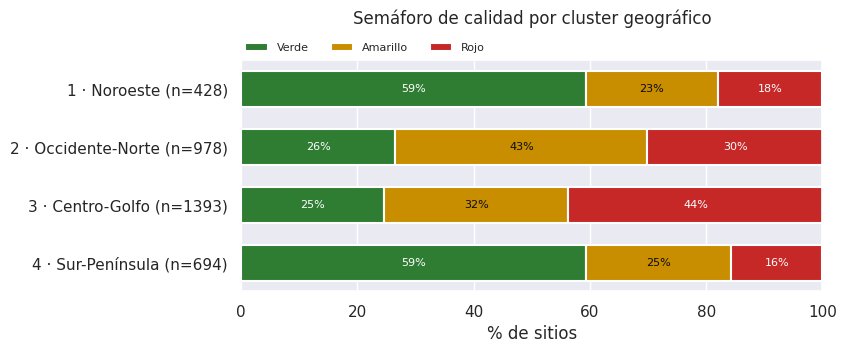

In [51]:
# Creamos gráficos para comparar la calidad del agua entre regiones.
def barras_semaforo(eje, porcentajes, titulo):
    izquierda = np.zeros(len(porcentajes))
    for color in ORDEN_SEMAFORO:
        valores = porcentajes[color].to_numpy()
        eje.barh(porcentajes.index.astype(str), valores, left=izquierda, height=0.62,
                 color=COLORES_SEMAFORO[color], edgecolor="white", linewidth=1.5, label=color)
        for y, (x0, v) in enumerate(zip(izquierda, valores)):
            if v >= 7:
                eje.text(x0 + v / 2, y, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                         color="white" if color != "Amarillo" else TINTA)
        izquierda += valores
    eje.set_xlim(0, 100); eje.invert_yaxis(); eje.grid(axis="y", visible=False)
    eje.set_xlabel("% de sitios"); eje.set_title(titulo, pad=26)
    eje.legend(ncols=3, loc="lower left", bbox_to_anchor=(-0.01, 0.99), frameon=False, fontsize=8)

fig, eje = plt.subplots(figsize=(7.5, 3))
etiquetas_cluster = pct_cluster.apply(lambda f: f"{f.name} · {f['region']} (n={f['sitios']})", axis=1)
barras_semaforo(eje, pct_cluster[ORDEN_SEMAFORO].set_axis(etiquetas_cluster), "Semáforo de calidad por cluster geográfico")
fig.savefig(RUTA_SALIDAS / "semaforo_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

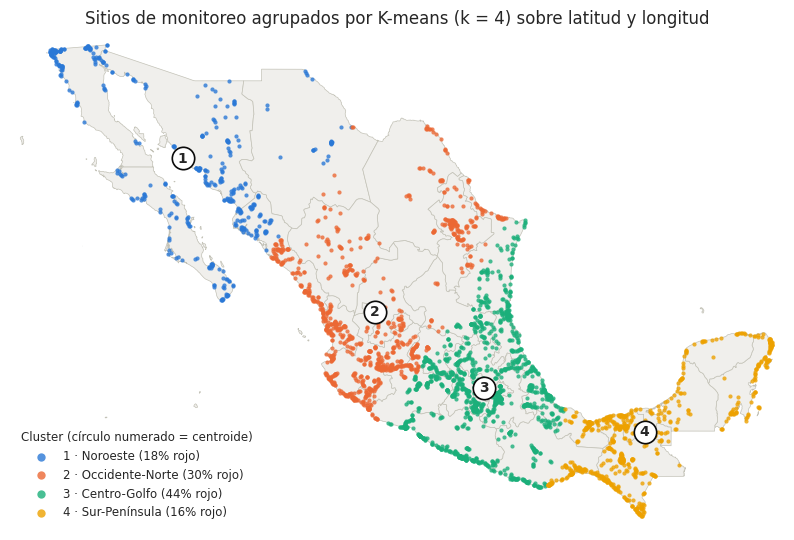

In [52]:
# Visualizamos los sitios y las regiones de K-means sobre el mapa de México.
fig, eje = plt.subplots(figsize=(10, 6.6))
if Path(RUTA_ESTADOS).exists() | es_url_https_valida(RUTA_ESTADOS):
  import geopandas as gpd
  gpd.read_file(RUTA_ESTADOS).plot(ax=eje, facecolor="#f0efec", edgecolor="#c3c2b7", linewidth=0.5)
eje.set_xlim(-118.8, -86.2); eje.set_ylim(14, 33.2); eje.set_aspect(1 / np.cos(np.radians(23.5)))
eje.set_axis_off(); eje.set_title(f"Sitios de monitoreo agrupados por K-means (k = {K}) sobre latitud y longitud")
for numero in range(1, K + 1):
    parte = df[df["CLUSTER"] == numero]
    eje.scatter(parte["LONGITUD"], parte["LATITUD"], s=9, color=COLORES_CLUSTER[numero - 1], alpha=0.8,
                linewidths=0, label=f"{numero} · {NOMBRES[numero]} ({pct_cluster.loc[numero, 'Rojo']:.0f}% rojo)")
eje.scatter(centroides["LONGITUD"], centroides["LATITUD"], s=260, color="white", edgecolor=TINTA, linewidth=1.2, zorder=4)
for numero, c in centroides.iterrows():
    eje.text(c["LONGITUD"], c["LATITUD"], str(numero), ha="center", va="center", fontsize=10, fontweight="bold", zorder=5)
eje.legend(title="Cluster (círculo numerado = centroide)", loc="lower left", frameon=False, fontsize=8.5, title_fontsize=8.5, markerscale=2)
fig.savefig(RUTA_SALIDAS / "mapa_kmeans_mexico.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
# Creamos el mapa interactivo de regiones y sitios de monitoreo.
CARTO_API_KEY = "cb1_3yrq_1_c8321e27216e0ad388b7731e"
mapa = folium.Map(
    location=[23.6, -102.5],
    zoom_start=5,
    tiles=None,
    prefer_canvas=True,
)
folium.TileLayer(
    tiles=f"https://basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}.png?key={CARTO_API_KEY}",
    attr="© OpenStreetMap contributors © CARTO",
    name="CartoDB positron",
).add_to(mapa)
capa_regiones = folium.FeatureGroup(name="Regiones K-means (envolvente de cada cluster)").add_to(mapa)
capa_sitios = folium.FeatureGroup(name="Sitios (color = semáforo)").add_to(mapa)
for numero in range(1, K + 1):
    parte = df[df["CLUSTER"] == numero]
    envolvente = MultiPoint(parte[COLS_GEO].to_numpy()).convex_hull
    folium.Polygon([(lat, lon) for lon, lat in envolvente.exterior.coords], color=COLORES_CLUSTER[numero - 1], weight=2,
                   fill=True, fill_opacity=0.12, tooltip=f"Cluster {numero} · {NOMBRES[numero]}").add_to(capa_regiones)
for fila in df.itertuples():
    folium.CircleMarker([fila.LATITUD, fila.LONGITUD], radius=3, weight=0, fill=True, fill_opacity=0.85,
                        fill_color=COLORES_SEMAFORO[fila.SEMAFORO],
                        tooltip=f"{str(fila.SITIO).title()} · cluster {fila.CLUSTER} · {fila.SEMAFORO}").add_to(capa_sitios)
for numero, c in centroides.iterrows():
    folium.Marker(
        [c["LATITUD"], c["LONGITUD"]],
        tooltip=f"Centroide {numero} · {NOMBRES[numero]}: {pct_cluster.loc[numero, 'Verde']:.0f}% verde, "
                f"{pct_cluster.loc[numero, 'Amarillo']:.0f}% amarillo, {pct_cluster.loc[numero, 'Rojo']:.0f}% rojo",
        icon=folium.DivIcon(html=f'<div style="width:24px;height:24px;border-radius:50%;background:#fff;border:2px solid #0b0b0b;'
                                 f'text-align:center;line-height:20px;font-weight:bold;font-size:12px;margin:-6px 0 0 -6px">{numero}</div>'),
    ).add_to(mapa)
folium.LayerControl(collapsed=False).add_to(mapa)
mapa.save(RUTA_SALIDAS / "/content/salidas/mapa_interactivo_kmeans.html")
mapa

In [54]:
# Resumimos la concentración de sitios y semáforos rojos por región.
rojos = df[Y].eq("Rojo")
for clusters, nombre in [([3], "Centro-Golfo"), ([2, 3], "Occidente-Norte + Centro-Golfo")]:
    en = df["CLUSTER"].isin(clusters)
    print(f"{nombre}: {en.mean():.0%} de los sitios y {rojos[en].sum() / rojos.sum():.0%} de los semáforos rojos del país")

Centro-Golfo: 40% de los sitios y 56% de los semáforos rojos del país
Occidente-Norte + Centro-Golfo: 68% de los sitios y 83% de los semáforos rojos del país


## 6. Sugerencia para discutir con el equipo: conclusión final

> **Estado de esta sección:** propuesta de redacción pendiente de discusión y aprobación. No se considera la conclusión definitiva del proyecto hasta que el equipo acuerde mantenerla o modificarla.

### Limpieza y análisis exploratorio

El archivo original contiene 4,141 filas y 55 columnas. Se eliminaron 648 filas completamente vacías, por lo que el análisis se realizó con 3,493 sitios de monitoreo válidos y con coordenadas completas. Los valores reportados por debajo del límite de detección, como `<2` o `<10`, se sustituyeron mediante la convención LD/2 exclusivamente para facilitar el análisis numérico; esta sustitución no representa la concentración exacta.

Los faltantes de las mediciones de calidad no se distribuyen al azar: dependen fuertemente del tipo de cuerpo de agua (`GRUPO`). Por ejemplo, los sitios costeros casi no registran DBO, DQO, coliformes o *E. coli*, mientras que en los grupos LÉNTICO y LÓTICO casi no se registran enterococos. Por esta razón, esos valores no se eliminaron de forma general y la matriz imputada del Pipeline se mantuvo únicamente como ejercicio didáctico, sin utilizarse en K-means ni para sustentar las conclusiones.

Las variables DBO, DQO, SST, coliformes fecales y *E. coli* presentan distribuciones con fuerte sesgo positivo y valores extremos. En estos casos, la mediana describe mejor el comportamiento típico que la media. Las correlaciones encontradas deben interpretarse con cautela porque cada par de variables puede contener un número diferente de observaciones disponibles.

### Resultados de K-means

K-means se aplicó únicamente a la longitud y latitud originales de los 3,493 sitios. Se seleccionó `k=4` porque coincide con el punto de codo de la inercia y permite representar cuatro regiones geográficas interpretables. Aunque `k=2` presenta el mayor coeficiente de silhouette (`0.503`), sus grupos son demasiado generales para el objetivo regional del proyecto. Con `k=4`, el silhouette es `0.410`, lo que indica una separación moderada entre los grupos.

La distribución del semáforo cambia entre los cuatro clústeres:

- **Noroeste:** 59.3 % verde y 18.0 % rojo.
- **Occidente-Norte:** 26.5 % verde y 30.2 % rojo.
- **Centro-Golfo:** 24.6 % verde y 43.8 % rojo.
- **Sur-Península:** 59.4 % verde y 15.7 % rojo.

Centro-Golfo presenta la mayor proporción de sitios rojos. Esta región contiene aproximadamente 40 % de los sitios monitoreados y 56 % de los registros rojos del conjunto de datos. En contraste, Noroeste y Sur-Península presentan las mayores proporciones de sitios verdes.

La prueba de independencia obtuvo χ²(6) = 452.5, `p < 0.001`, y V de Cramér = 0.255. Por tanto, se rechaza la hipótesis de independencia entre el clúster geográfico y el semáforo. Sin embargo, V de Cramér indica que la asociación es de magnitud baja a moderada: la ubicación geográfica está relacionada con la calidad observada, pero no la determina por sí sola.

### Respuesta a la pregunta del proyecto

**Sí se encontró una relación estadísticamente significativa entre la ubicación geográfica y la calidad del agua en los sitios monitoreados por CONAGUA durante 2020.** Los porcentajes de semáforo verde, amarillo y rojo cambian entre las regiones obtenidas mediante K-means. No obstante, la intensidad de la asociación es limitada y también intervienen factores como el tipo de cuerpo de agua, las actividades humanas, las características de cada cuenca y los diferentes protocolos de medición.

Estos resultados son observacionales y no demuestran causalidad. Corresponden exclusivamente a sitios de monitoreo de aguas superficiales durante 2020; no representan todos los cuerpos de agua de México, no permiten evaluar directamente la calidad del agua potable domiciliaria y no deben utilizarse por sí solos para recomendar un estado para vivir o determinar si el agua puede consumirse.

### Puntos para acordar en la reunión

- Confirmar si esta redacción responde claramente a la pregunta principal del proyecto.
- Aprobar o ajustar la interpretación de la asociación entre región y semáforo.
- Confirmar que se mantengan las limitaciones sobre causalidad, potabilidad y recomendaciones de vivienda.
- Una vez aprobada, cambiar el título de esta sección a **Conclusiones finales**.